In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import pickle

print(os.getcwd())  # Should show the project root 

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES, REPRESENTATIVES_FOR_GOALS


%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/B_pca_and_pareto_trade-off


In [2]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis")
output_folder.mkdir(exist_ok=True)


with open(output_folder / "all_datasets_precise_categories.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)

In [3]:
ordered_dataset_names = ['hcp_schaefer_100_dataset_gnm', 
                        # 'hcp_schaefer_100_dataset', 
                        'suarez_MaMI_dataset', 
                        'lexis_data_young', 
                        'lexis_data_aging',
                        'lexis_data_developing', 
                        'kaysons_generated_networks_diffusion', 
                        'kaysons_generated_networks_propagation', 
                        'kaysons_generated_networks_routing', 
                        # 'kaysons_generated_networks_topology', 
                        ]

In [4]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name in ordered_dataset_names: 
    df = dict_with_all_datasets[dataset_name]
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology" or dataset_name == "hcp_schaefer_100_dataset": 
        print(" ---> skipped")
        continue
    huge_df = pd.concat([huge_df, df], ignore_index=True)
    

# First count how many rows have all NaN values in the metric columns
# metric_columns = [col for col in huge_df.columns if col not in ["dataset", "age"]]
# num_all_nan_rows = huge_df[metric_columns].isna().all(axis=1).sum()
# print(f"Number of rows with all NaN values in metric columns: {num_all_nan_rows}")  
# # Remove any rows in huge_df that are completely empty 
# # huge_df.dropna(how="all", inplace=True)

hcp_schaefer_100_dataset_gnm 25000
suarez_MaMI_dataset 224
lexis_data_young 703
lexis_data_aging 687
lexis_data_developing 629
kaysons_generated_networks_diffusion 1
kaysons_generated_networks_propagation 1
kaysons_generated_networks_routing 1


In [5]:

# Only get huge_df entries for datasets containing "lexis_data"
huge_df = huge_df[huge_df["dataset"].str.contains("lexis_data")]

In [6]:
huge_df['color_dataset'] = huge_df['dataset'].map(COLOR_SCHEME)

In [7]:
huge_df

,transitivity,avg_clustering,modularity,degree_gini,degree_assortativity,omega,structural_complexity,directed_simplices_count,directed_simplices_max_size,eta,...,computational_capacity_memory_nonlinear_ratio,computational_capacity_total_capacity,computational_capacity_state_dimensionality,computational_capacity_state_entropy,computational_capacity_state_rank,computational_capacity_separation_ratio,computational_capacity_lyapunov_exponent,mc_mean,dataset,color_dataset
25224,0.447657,0.500467,0.502173,0.271475,0.311591,0.088988,0.752183,164.0,9.0,NaN,...,0.711990,20.115900,1.417760,0.532775,100.0,1.958217,-0.140315,8.703271,lexis_data_young,#5DC400
25225,0.421781,0.479110,0.482583,0.265596,0.200417,0.136855,0.763829,168.0,8.0,NaN,...,0.718483,22.192609,1.467275,0.596728,100.0,1.962743,-0.113200,8.568311,lexis_data_young,#5DC400
25226,0.433155,0.465811,0.481428,0.298828,0.274818,0.165312,0.745449,157.0,9.0,NaN,...,0.711876,20.177980,1.307521,0.473058,100.0,1.966536,-0.120126,8.479803,lexis_data_young,#5DC400
25227,0.426840,0.436832,0.471413,0.261717,0.347657,0.182278,0.764888,172.0,9.0,NaN,...,0.715152,22.320992,1.513297,0.628864,100.0,1.958587,-0.119530,8.613952,lexis_data_young,#5DC400
25228,0.442505,0.465549,0.423224,0.308725,0.431438,0.156259,0.744151,180.0,9.0,NaN,...,0.721773,19.749880,1.359903,0.520695,100.0,1.969301,-0.128243,8.148274,lexis_data_young,#5DC400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27238,0.483425,0.516129,0.534807,0.256707,0.384640,0.064421,0.742424,164.0,8.0,NaN,...,0.718645,18.623567,1.268727,0.425066,100.0,1.963236,-0.125503,8.280445,lexis_data_developing,#A6587C
27239,0.439680,0.497878,0.499037,0.229838,0.278070,0.075438,0.767917,154.0,8.0,NaN,...,0.721666,20.403865,1.313455,0.476297,100.0,1.973667,-0.119599,8.446714,lexis_data_developing,#A6587C
27240,0.443023,0.490965,0.513394,0.220931,0.222922,0.084870,0.769978,155.0,9.0,NaN,...,0.712339,21.085888,1.386365,0.527633,100.0,1.969293,-0.123960,8.525673,lexis_data_developing,#A6587C
27241,0.420825,0.460781,0.517178,0.212970,0.288585,0.149468,0.780745,168.0,7.0,NaN,...,0.702456,22.158600,1.489472,0.605204,100.0,1.966739,-0.125366,8.936001,lexis_data_developing,#A6587C


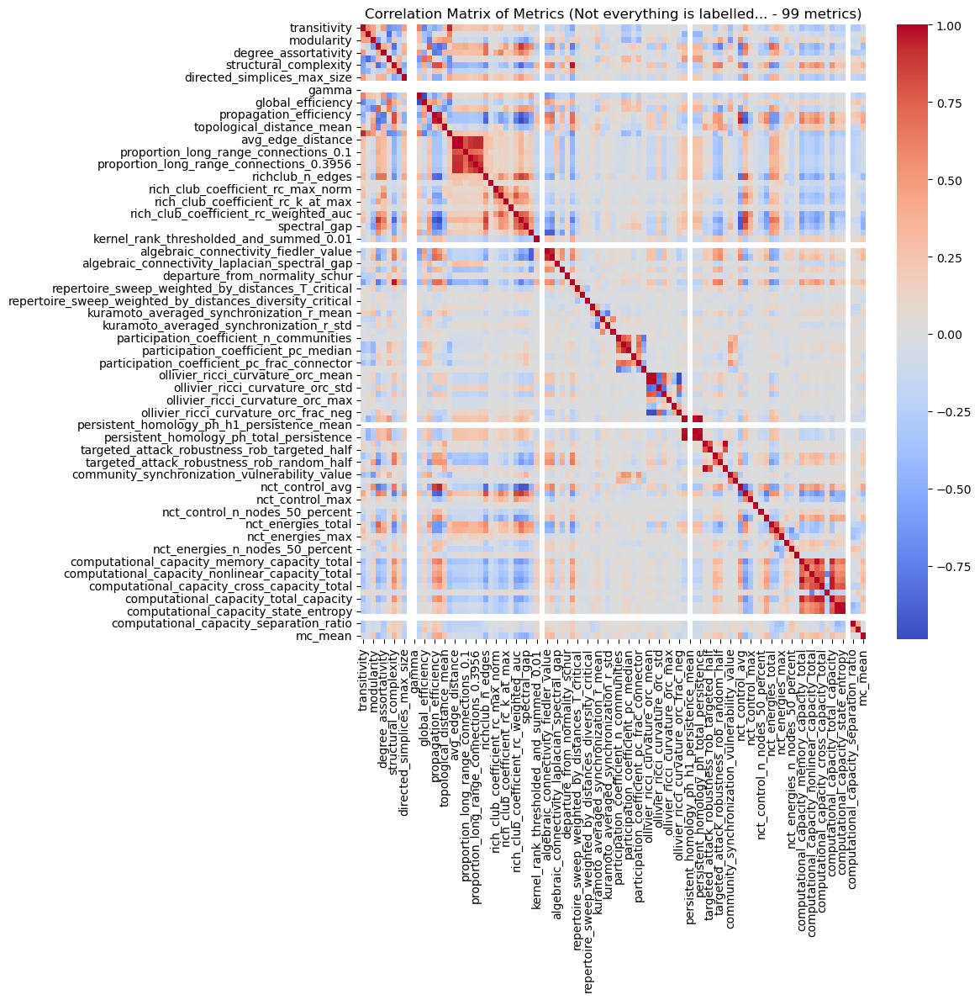

In [8]:
# For pca always drop the dataset column and only use the metric columns
huge_df_properties = huge_df.drop(columns=["dataset", "color_dataset"])

# Make a correlation axis between the columns of the huge_df. Don't use the dataset column for this, only the metric columns.
correlation_matrix = huge_df_properties.corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=False, # fmt=".2f", 
            cmap="coolwarm", cbar=True)
plt.title(f"Correlation Matrix of Metrics (Not everything is labelled... - {correlation_matrix.shape[0]} metrics)")
plt.tight_layout()
plt.show()
# Not everything is labelled... 

In [9]:
# import re
# from config import PROPERTY_NAMES

# # ── Category definitions ──────────────────────────────────────────────────────
# remaining_categories = {
#     "Fundamental Topology": [ 
#         # "transitivity", # corr too highly with avg_clustering
#         # "avg_clustering", # omega
#         "modularity", 
#         # "degree_gini", # too high corr with spectral_radius
#         "degree_assortativity", 
#         "omega", 
#         # "structural_complexity", 
        
#         "directed_simplices_count", # Higher order
#         "directed_simplices_max_size",
        
#         # "energy" # i.e.: Fit to networks - maybe remove again? 
#     ],
#     "Paths, Efficiency & Communication": [
#         "char_path_length", 
#         # "global_efficiency", # corr too highly with omega
#         "diffusion_efficiency",
#         # "propagation_efficiency", # corr too highly with diffusion_efficiency
#         # "avg_communicability", # corr too highly with spectral_radius # !!!!!!!
#         "topological_distance_mean", 
#         # "topological_distance_std",
#     ],
#     "Spatial Embedding & Wiring Cost": [
#         # "avg_edge_distance", 
#         "wiring_cost",
#         # "proportion_long_range_connections_0.1",
#         # "proportion_long_range_connections_0.3",
#         "proportion_long_range_connections_0.3956",
#         # "proportion_long_range_connections_0.5",
#     ],
#     "Rich-Club Organization": [
#         # "richclub_n_edges", 
#         "richclub_avg_length",
#         "rich_club_coefficient_rc_max_norm",
#         "rich_club_coefficient_rc_mean_norm",
#         "rich_club_coefficient_rc_k_at_max",
#         "rich_club_coefficient_rc_regime_frac",
#         "rich_club_coefficient_rc_weighted_auc",
#     ],
#     "Spectral Properties, Algebraic Connectivity & Fiedler Analysis": [
#         "spectral_radius", 
#         "spectral_gap", # Has exactly the same output as Fatemehs version, bc it is identical (lambda_n - lambda_(n-1))
#         "synchronizability_eigenratio_eigenratio", # lambda_n / lambda_2

#         "kernel_rank_thresholded_and_summed_0.01",          # np.sum(np.abs(eigs) > threshold * np.abs(eigs).max())
#         "kernel_rank_phase_diff_of_lambda_max_and_2nd",     # np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max())
        
#         "algebraic_connectivity_fiedler_value", # Relies on a different library, I hope? 
#         # "algebraic_connectivity_fiedler_value_norm",
#         "algebraic_connectivity_laplacian_spectral_gap",
#         "algebraic_connectivity_fiedler_bipartition_balance",
        
#         "departure_from_normality_schur",

#         # "effective_dimensionality", # corr too highly with omega
#     ],
#     "Metastability & Kuramoto Synchronization": [ 
#         "repertoire_sweep_weighted_by_distances_T_critical",
#         "repertoire_sweep_weighted_by_distances_size_critical",
#         "repertoire_sweep_weighted_by_distances_diversity_critical", 
        
#         "kuramoto_averaged_synchronization_r_final",
#         "kuramoto_averaged_synchronization_r_mean",
#         "kuramoto_averaged_synchronization_r_mean_se",
#         "kuramoto_averaged_synchronization_r_std",
#         "kuramoto_averaged_synchronization_r_std_se",
#     ],

#     "Participation Coefficient (Louvain)": [
#         "participation_coefficient_n_communities",
#         # "participation_coefficient_pc_mean", # corr too highly with omega
#         # "participation_coefficient_pc_median",
#         "participation_coefficient_pc_std",
#         "participation_coefficient_pc_frac_connector",
#         "participation_coefficient_wmd_std",
#     ],
#     "Ollivier-Ricci Curvature": [
#         "ollivier_ricci_curvature_orc_mean",
#         # "ollivier_ricci_curvature_orc_median",
#         "ollivier_ricci_curvature_orc_std",
#         "ollivier_ricci_curvature_orc_min",
#         "ollivier_ricci_curvature_orc_max",
#         "ollivier_ricci_curvature_orc_skewness",
#         "ollivier_ricci_curvature_orc_frac_neg",
#     ],
#     # "Persistent Homology (TDA)": [
#     #     # "persistent_homology_ph_h1_n_features",
#     #     # "persistent_homology_ph_h1_persistence_mean",
#     #     # "persistent_homology_ph_h1_entropy",
#     #     # "persistent_homology_ph_total_persistence",
#     # ],

#     "Targeted Attack Robustness & Community Structure & Vulnerability": [
#         "targeted_attack_robustness_rob_targeted_auc",
#         # "targeted_attack_robustness_rob_targeted_half",
#         # "targeted_attack_robustness_rob_random_auc", # corr too highly with 'char_path_length'
#         # "targeted_attack_robustness_rob_random_half",
#         "targeted_attack_robustness_rob_ratio",
        
#         # "community_synchronization_vulnerability_value", # too high corr with participation_coefficient_pc_frac_connector
#         "community_synchronization_vulnerability_n_communities",
#         ],
#     "Network Control Theory - Average Controllability": [
#         "nct_control_avg",
#         # "nct_control_std", 
#         "nct_control_max",
#         "nct_control_n_nodes_90_percent",
#         "nct_control_n_nodes_50_percent",
#         "nct_control_n_nodes_10_percent",
#     ],
#     "Network Control Theory - Control Energy": [
#         "nct_energies_total",
#         "nct_energies_std", 
#         "nct_energies_max",
#         "nct_energies_n_nodes_90_percent",
#         "nct_energies_n_nodes_50_percent",
#         "nct_energies_n_nodes_10_percent",
#     ],
#     "Computational Capacity": [
#         "computational_capacity_memory_capacity_total",
#         # "computational_capacity_memory_timescale",
#         "computational_capacity_nonlinear_capacity_total",
#         # "computational_capacity_cubic_capacity_total",
#         # "computational_capacity_cross_capacity_total",
#         "computational_capacity_memory_nonlinear_ratio",
#         # "computational_capacity_total_capacity",
#         "computational_capacity_state_dimensionality",
#         # "computational_capacity_state_entropy",
#         "computational_capacity_state_rank",
#         "computational_capacity_separation_ratio",
#         "computational_capacity_lyapunov_exponent",
#     ],
#     # "Reservoir Computing - Basic Measures": 
#     "Memory Capacity - Full Lag Profile": [
#         # [f"mc_{i}" for i in range(1, 50)]
#         "mc_mean" # , "mc_std"]
#     ],
# }


# precise_categories = []
# for cat_name, cat_cols in remaining_categories.items(): 
    
#     for col in cat_cols:
#         precise_categories.append(col)


# # precise_categories

In [10]:
import re
from config import PROPERTY_NAMES

# ── Category definitions ──────────────────────────────────────────────────────
remaining_categories = {
    "Fundamental Topology": [ 
        # "transitivity", # corr too highly with avg_clustering
        "avg_clustering", # omega # CHANGED HACK 
        "modularity", 
        # "degree_gini", # too high corr with spectral_radius
        "degree_assortativity", 
        # "omega", 
        # "structural_complexity", 
        
        "directed_simplices_count", # Higher order
        "directed_simplices_max_size",
        
        # "energy" # i.e.: Fit to networks - maybe remove again? 
    ],
    "Paths, Efficiency & Communication": [
        "char_path_length", 
        # "global_efficiency", # corr too highly with omega
        "diffusion_efficiency",
        # "propagation_efficiency", # corr too highly with diffusion_efficiency
        # "avg_communicability", # corr too highly with spectral_radius # !!!!!!!
        "topological_distance_mean", 
        # "topological_distance_std",
    ],
    "Spatial Embedding & Wiring Cost": [
        # "avg_edge_distance", 
        "wiring_cost",
        # "proportion_long_range_connections_0.1",
        # "proportion_long_range_connections_0.3",
        "proportion_long_range_connections_0.3956",
        # "proportion_long_range_connections_0.5",
    ],
    "Rich-Club Organization": [
        # "richclub_n_edges", 
        "richclub_avg_length",
        "rich_club_coefficient_rc_max_norm",
        "rich_club_coefficient_rc_mean_norm",
        "rich_club_coefficient_rc_k_at_max",
        "rich_club_coefficient_rc_regime_frac",
        "rich_club_coefficient_rc_weighted_auc",
    ],
    "Spectral Properties, Algebraic Connectivity & Fiedler Analysis": [
        "spectral_radius", 
        "spectral_gap", # Has exactly the same output as Fatemehs version, bc it is identical (lambda_n - lambda_(n-1))
        "synchronizability_eigenratio_eigenratio", # lambda_n / lambda_2

        "kernel_rank_thresholded_and_summed_0.01",          # np.sum(np.abs(eigs) > threshold * np.abs(eigs).max())
        "kernel_rank_phase_diff_of_lambda_max_and_2nd",     # np.angle(eigs[np.argsort(np.abs(eigs))[-2]]) - np.angle(eigs.max())
        
        "algebraic_connectivity_fiedler_value", # Relies on a different library, I hope? 
        # "algebraic_connectivity_fiedler_value_norm",
        "algebraic_connectivity_laplacian_spectral_gap",
        "algebraic_connectivity_fiedler_bipartition_balance",
        
        "departure_from_normality_schur",

        # "effective_dimensionality", # corr too highly with omega
    ],
    "Metastability & Kuramoto Synchronization": [ 
        "repertoire_sweep_weighted_by_distances_T_critical",
        "repertoire_sweep_weighted_by_distances_size_critical",
        "repertoire_sweep_weighted_by_distances_diversity_critical", 
        
        "kuramoto_averaged_synchronization_r_final",
        "kuramoto_averaged_synchronization_r_mean",
        "kuramoto_averaged_synchronization_r_mean_se",
        "kuramoto_averaged_synchronization_r_std",
        "kuramoto_averaged_synchronization_r_std_se",
    ],

    "Participation Coefficient (Louvain)": [
        "participation_coefficient_n_communities",
        # "participation_coefficient_pc_mean", # corr too highly with omega (and avg_communicabiltiy)
        # "participation_coefficient_pc_median",
        "participation_coefficient_pc_std",
        "participation_coefficient_pc_frac_connector",
        "participation_coefficient_wmd_std",
    ],
    "Ollivier-Ricci Curvature": [
        "ollivier_ricci_curvature_orc_mean",
        # "ollivier_ricci_curvature_orc_median",
        "ollivier_ricci_curvature_orc_std",
        "ollivier_ricci_curvature_orc_min",
        "ollivier_ricci_curvature_orc_max",
        "ollivier_ricci_curvature_orc_skewness",
        "ollivier_ricci_curvature_orc_frac_neg",
    ],
    # "Persistent Homology (TDA)": [
    #     # "persistent_homology_ph_h1_n_features",
    #     # "persistent_homology_ph_h1_persistence_mean",
    #     # "persistent_homology_ph_h1_entropy",
    #     # "persistent_homology_ph_total_persistence",
    # ],

    "Targeted Attack Robustness & Community Structure & Vulnerability": [
        "targeted_attack_robustness_rob_targeted_auc",
        # "targeted_attack_robustness_rob_targeted_half",
        # "targeted_attack_robustness_rob_random_auc", # corr too highly with 'char_path_length'
        # "targeted_attack_robustness_rob_random_half",
        "targeted_attack_robustness_rob_ratio",
        
        # "community_synchronization_vulnerability_value", # too high corr with participation_coefficient_pc_frac_connector
        "community_synchronization_vulnerability_n_communities",
        ],
    "Network Control Theory - Average Controllability": [
        "nct_control_avg",
        # "nct_control_std", 
        "nct_control_max",
        "nct_control_n_nodes_90_percent",
        "nct_control_n_nodes_50_percent",
        "nct_control_n_nodes_10_percent",
    ],
    "Network Control Theory - Control Energy": [
        "nct_energies_total",
        "nct_energies_std", 
        "nct_energies_max",
        "nct_energies_n_nodes_90_percent",
        "nct_energies_n_nodes_50_percent",
        "nct_energies_n_nodes_10_percent",
    ],
    "Computational Capacity": [
        "computational_capacity_memory_capacity_total",
        # "computational_capacity_memory_timescale",
        "computational_capacity_nonlinear_capacity_total",
        # "computational_capacity_cubic_capacity_total",
        # "computational_capacity_cross_capacity_total",
        "computational_capacity_memory_nonlinear_ratio",
        # "computational_capacity_total_capacity",
        "computational_capacity_state_dimensionality",
        # "computational_capacity_state_entropy",
        "computational_capacity_state_rank",
        "computational_capacity_separation_ratio",
        "computational_capacity_lyapunov_exponent",
    ],
    # "Reservoir Computing - Basic Measures": 
    "Memory Capacity - Full Lag Profile": [
        # [f"mc_{i}" for i in range(1, 50)]
        "mc_mean" # , "mc_std"]
    ],
}


precise_categories = []
for cat_name, cat_cols in remaining_categories.items(): 
    
    for col in cat_cols:
        precise_categories.append(col)


# precise_categories

In [11]:
from config import PROPERTY_NAMES

# --- Config ---
THRESHOLD = 0.95  # only flag pairs above this

# Start fresh each run from the full metric set
remaining_cols = huge_df_properties.columns.tolist()
print(len(remaining_cols), "columns before removals")
# remove all columns that are not in PROPERTY_NAMES.keys(): 
remaining_cols = [c for c in remaining_cols if c in precise_categories] # PROPERTY_NAMES.keys()]
print(len(remaining_cols), "columns after removing those not in 'precise_categories'")

to_remove = [
#             "participation_coefficient_pc_median_further", "participation_coefficient_pc_std_further", 
#              "kernel_rank_max", 
#              "spectral_gap", # 100 % identical to fatemeh
#              "participation_coefficient_wmd_mean_further", "participation_coefficient_wmd_std_further",
#              "participation_coefficient_n_communities_further", 
#              "persistent_homology_ph_total_persistence", # identical to "h1_n_features"
#              'participation_coefficient_pc_mean_further', 
#              "synchronizability_eigenratio_lambda_2", # same as fiedler value
#              "participation_coefficient_pc_frac_connector_further", 
#              "algebraic_connectivity_fiedler_value", 
#              "algebraic_connectivity_fiedler_value_norm", 
#              "computational_capacity_cubic_capacity_total", 
#              "avg_edge_distance", 
#              "structural_complexity", # too high correlation with "effective_dimensionality"
#              "topological_distance_std",
#              "transitivity", # too high correlation with "avg_clustering"
#              "computational_capacity_cross_capacity_total", 
#              'omega', # too high correlation with "omega"
#              'computational_capacity_state_entropy', 
#              "participation_coefficient_pc_median", 
#              "proportion_long_range_connections_0.3", 'proportion_long_range_connections_0.5', 'proportion_long_range_connections_0.1', 
#              "targeted_attack_robustness_rob_random_half", 
#              'participation_coefficient_pc_mean', 
#              'char_path_length', 
#              'nct_control_std', 
#             'computational_capacity_total_capacity', 
#             'participation_coefficient_pc_frac_connector', 
#             'propagation_efficiency', 
#             'spectral_radius', # avg_commmunicability 
#             'persistent_homology_ph_h1_entropy', 
#             'computational_capacity_memory_timescale', 
#             'richclub_n_edges', # too high correlation with avg_communicability
#             'community_synchronization_vulnerability_value', 
             
#              "effective_dimensionality", # !!! (propagation_efficiency)
             
#              "ollivier_ricci_curvature_orc_mean", 
#              "targeted_attack_robustness_rob_targeted_half", 
             ] #+ [f"mc_{i}" for i in range(1,15)] + [f"mc_{i}" for i in range(16,50)]

if to_remove is not None:
    remaining_cols = [c for c in remaining_cols if c not in to_remove]


# ── Run this cell repeatedly ──────────────────────────────────────────────────
working_df = huge_df_properties[remaining_cols].copy()
corr = working_df.corr().abs()

# Zero out diagonal and lower triangle to avoid duplicates
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_upper = corr.where(mask)

# Find the single highest correlation
max_corr = corr_upper.stack().max()
max_pair = corr_upper.stack().idxmax()

if max_corr < THRESHOLD:
    print(f"✅ No correlations above {THRESHOLD}. Done! {len(remaining_cols)} variables remain.")
    print(f"Removed so far: {to_remove}")
else:
    var_a, var_b = max_pair
    print(f"⚠️  Highest correlation: {max_corr:.4f}")
    print(f"   → '{var_a}'")
    print(f"   → '{var_b}'")
    print()
    
    # Show each variable's mean absolute correlation with everything else
    # (helps you decide which is more redundant)
    mean_corr_a = corr_upper[var_a].fillna(corr_upper.T[var_a]).mean()
    mean_corr_b = corr_upper[var_b].fillna(corr_upper.T[var_b]).mean()
    print(f"   Mean |corr| with others:  '{var_a}' = {mean_corr_a:.3f}  |  '{var_b}' = {mean_corr_b:.3f}")
    print(f"   (Higher mean → more redundant overall → better candidate to drop)")
    print()
    # print("👉 Add one to `to_remove`, then re-run this cell:")
    # print(f"   to_remove.append('{var_a}')   # or '{var_b}'")

# # Apply removals
# remaining_cols = [c for c in huge_df_metrics.columns if c not in to_remove]
print(f"\n🗑️  Removed so far ({len(to_remove)}): {to_remove}")
print(f"📊 Remaining variables: {len(remaining_cols)}")

99 columns before removals
65 columns after removing those not in 'precise_categories'
⚠️  Highest correlation: 0.9914
   → 'targeted_attack_robustness_rob_targeted_auc'
   → 'targeted_attack_robustness_rob_ratio'

   Mean |corr| with others:  'targeted_attack_robustness_rob_targeted_auc' = 0.096  |  'targeted_attack_robustness_rob_ratio' = 0.086
   (Higher mean → more redundant overall → better candidate to drop)


🗑️  Removed so far (0): []
📊 Remaining variables: 65


In [12]:
# Apply the selection
huge_df_properties = huge_df_properties[remaining_cols]

Dropped columns: []


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_27237/3178215358.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


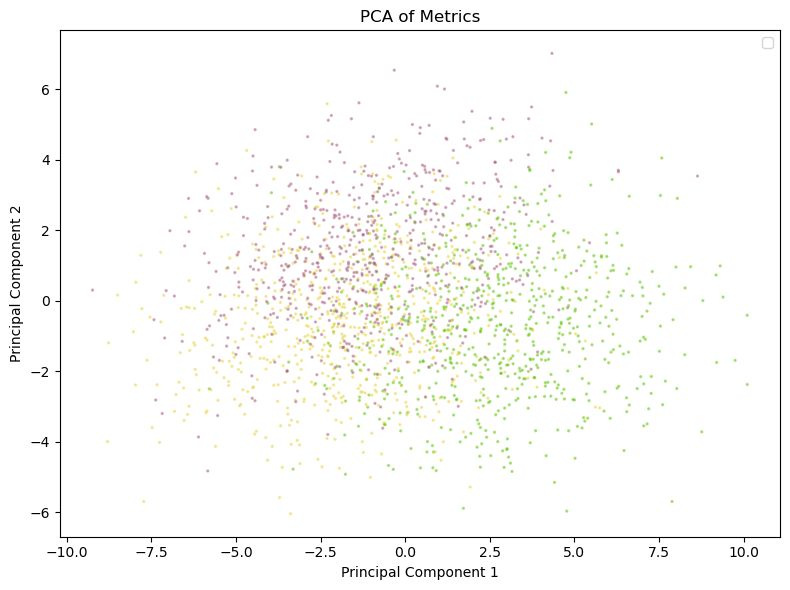

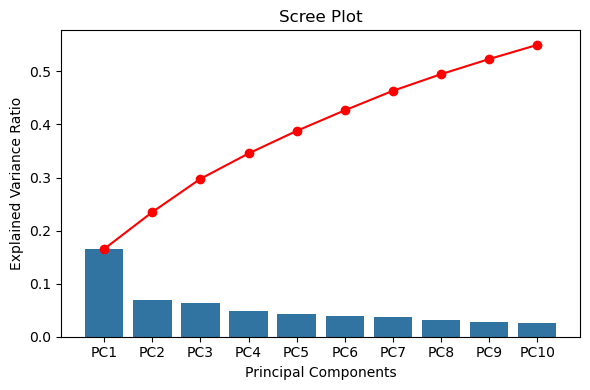

In [13]:
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# # print all max values of all columns in huge_df_metrics
# print("\nMax values of metrics:")
# for col in huge_df_metrics.columns:
#     print(f"{col}: {huge_df_metrics[col].max():.4f}")
# print("\nMin values of metrics:")
# for col in huge_df_metrics.columns:
#     print(f"{col}: {huge_df_metrics[col].min():.4f}")
    
# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=2, 
            alpha=0.4, 
            c=huge_df['color_dataset'], 
            # label=huge_df['dataset']
        )
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

In [169]:
# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0]))[::-1]
# sorted_indices = np.argsort(np.abs(loadings[:, 0]) + np.abs(loadings[:, 1]))[::-1]
abs_ordered_loadings = np.abs(loadings[sorted_indices, 0])
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

print("Top 30 contributors to PC1:")
for i in range(30):
    print(f"     {metric_names[i]}          {abs_ordered_loadings[i]}") # : {loadings[i, 0]:.4f}")

Top 30 contributors to PC1:
     avg_clustering          0.18017615817408478
     participation_coefficient_pc_frac_connector          0.1790056786436598
     degree_assortativity          0.17594042431934676
     nct_control_n_nodes_50_percent          0.17573497687993847
     algebraic_connectivity_fiedler_value          0.17511777255855174
     directed_simplices_max_size          0.17031838336031402
     departure_from_normality_schur          0.16950712316151678
     nct_control_n_nodes_10_percent          0.16554684802581318
     nct_control_max          0.1648949013938812
     computational_capacity_nonlinear_capacity_total          0.16489136249186262
     computational_capacity_memory_capacity_total          0.16360910265894138
     modularity          0.16002498563235223
     spectral_radius          0.1596345328891103
     char_path_length          0.15912715738329763
     rich_club_coefficient_rc_weighted_auc          0.15823306598194326
     nct_energies_std          0.157

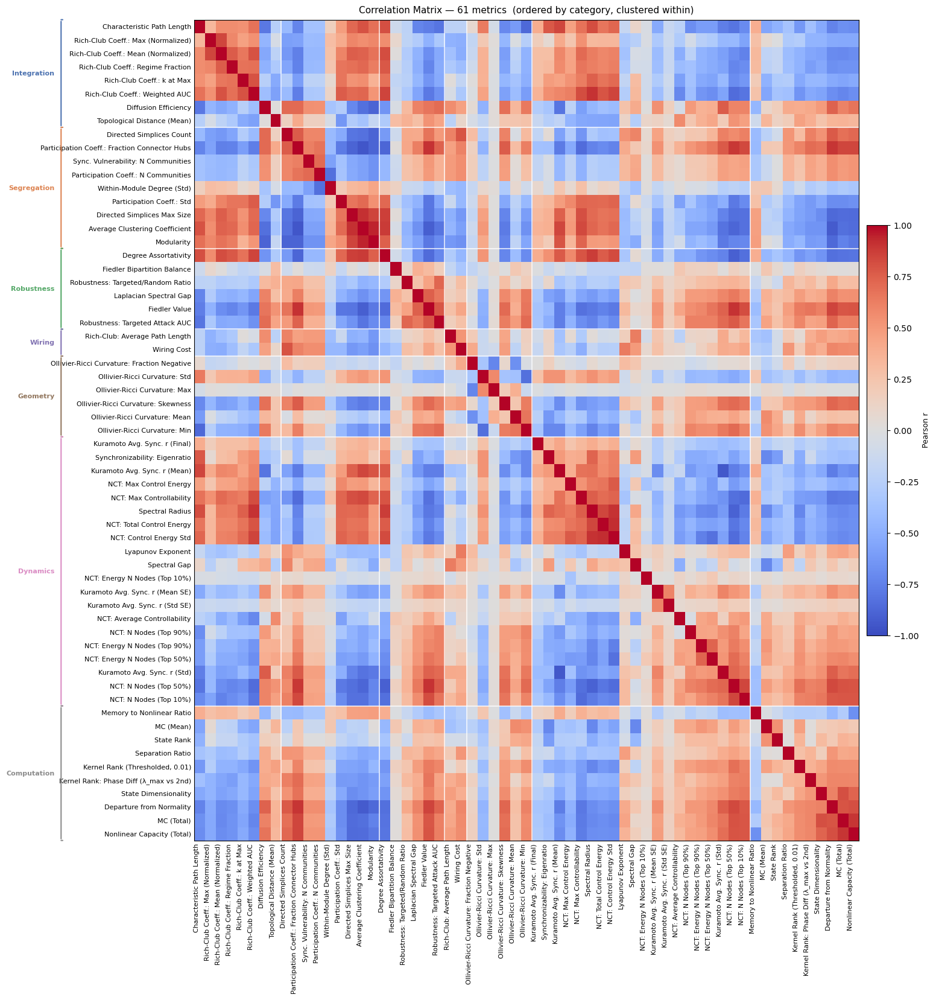

Saved: corr_matrix_categorised.pdf


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# ── 1. Load category / section metadata from Excel ────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx" # network_properties_full_excel.xlsx"   # ← adjust path if needed
meta_raw = pd.read_excel(excel_path, sheet_name=0)

# Forward-fill the section headers (rows where 'Variable Name' is NaN)
meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

# Keep only actual variable rows
meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)

# Preferred display order for broad categories
CATEGORY_ORDER = [
    "Integration", "Segregation", "Robustness",
    "Topology", "Wiring", "Geometry",
    "Dynamics", "Computation",
]

# Colour palette — one colour per broad category
CATEGORY_COLOURS = {
    "Integration":  "#4C72B0",
    "Segregation":  "#DD8452",
    "Robustness":   "#55A868",
    "Topology":     "#C44E52",
    "Wiring":       "#8172B2",
    "Geometry":     "#937860",
    "Dynamics":     "#DA8BC3",
    "Computation":  "#8C8C8C",
}

# ── 2. Filter to only the variables present in your reduced_corr ──────────────
# (replace `remaining_cols` and `huge_df` with your actual variable names / df)
cols_in_data = [c for c in huge_df_properties.keys() if c in meta.index]

# Assign a sort key: primary = category order index, secondary = section string
def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, str(row["section"]))

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df_properties.corr() # huge_df[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue

    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    # Convert correlation to distance; clip to avoid numerical issues
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method="average")
    order = leaves_list(Z)
    final_order.extend([cat_cols[i] for i in order])

# Variables not assigned a known category — append at end
uncategorised = [c for c in cols_in_data if c not in final_order]
final_order.extend(uncategorised)

# ── 4. Reorder correlation matrix ─────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]

# ── 5. Build display labels (use PROPERTY_NAMES where available) ──────────────
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 6. Build category colour arrays for the side-bar ─────────────────────────
bar_colours = []
for c in final_order:
    cat = meta.loc[c, "Category"] if c in meta.index else None
    bar_colours.append(CATEGORY_COLOURS.get(cat, "#CCCCCC"))

# ── 7. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig_size = max(16, n * 0.22)
fig = plt.figure(figsize=(fig_size + 1.5, fig_size))

# Single axes — brackets will be drawn to the left in axes/figure coordinates
gs = gridspec.GridSpec(
    1, 1,
    left=0.22, right=0.97,
    top=0.97, bottom=0.12,
)

ax_heat = fig.add_subplot(gs[0])

# — Heatmap —
im = ax_heat.imshow(
    reduced_corr.values,
    cmap="coolwarm", vmin=-1, vmax=1,
    aspect="auto", interpolation="none",
)

# Draw thin white lines between categories to visually separate them
boundaries = [0]
prev_cat = meta.loc[final_order[0], "Category"] if final_order[0] in meta.index else None
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax_heat.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax_heat.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
tick_fontsize = 8
ax_heat.set_xticks(np.arange(n))
ax_heat.set_xticklabels(new_labels, rotation=90, fontsize=tick_fontsize, ha="right")
ax_heat.set_yticks(np.arange(n))
ax_heat.set_yticklabels(new_labels, fontsize=tick_fontsize)
ax_heat.tick_params(axis="both", which="both", length=0)

# ── Draw category brackets to the left of y-tick labels ──────────────────────
# We work in axes coordinates (0-1 in both x and y).
# y=0 is bottom of axes, y=1 is top; row 0 (first variable) is at the TOP.

# Build a map: category → (first_row_index, last_row_index)  [0-based, top-down]
cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    if cat not in cat_row_spans:
        cat_row_spans[cat] = [row_i, row_i]
    else:
        cat_row_spans[cat][1] = row_i

def row_to_axes_y(row_i, n):
    """Convert a 0-based top-down row index to matplotlib axes y coordinate."""
    # imshow row 0 is plotted at y = (n-0.5)/n  →  top
    return 1.0 - (row_i + 0.5) / n

BRACKET_X   = -0.2 # -0.015   # axes x where the vertical bar of the bracket sits
TICK_OFFSET = -0.005   # small horizontal serifs
LABEL_X     = -0.21 # -0.025   # axes x for the category name text

trans = ax_heat.transAxes  # all coordinates in axes fraction

for cat, (r_first, r_last) in cat_row_spans.items():
    colour = CATEGORY_COLOURS.get(cat, "#444444")
    y_top    = row_to_axes_y(r_first, n) + 0.5 / n   # top edge of first row
    y_bottom = row_to_axes_y(r_last,  n) - 0.5 / n   # bottom edge of last row
    y_mid    = (y_top + y_bottom) / 2

    # Vertical bar
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_bottom), xytext=(BRACKET_X, y_top),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.5),
        annotation_clip=False,
    )
    # Top serif
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_top), xytext=(BRACKET_X - TICK_OFFSET, y_top),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.5),
        annotation_clip=False,
    )
    # Bottom serif
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_bottom), xytext=(BRACKET_X - TICK_OFFSET, y_bottom),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.5),
        annotation_clip=False,
    )
    # Category label
    ax_heat.text(
        LABEL_X, y_mid, cat,
        transform=trans,
        ha="right", va="center",
        fontsize=8, fontweight="bold",
        color=colour,
        clip_on=False,
    )

# Colour-bar legend
cbar = fig.colorbar(im, ax=ax_heat, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)

ax_heat.set_title(
    f"Correlation Matrix — {n} metrics  (ordered by category, clustered within)",
    fontsize=11, pad=8,
)

plt.savefig("corr_matrix_categorised.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: corr_matrix_categorised.pdf")

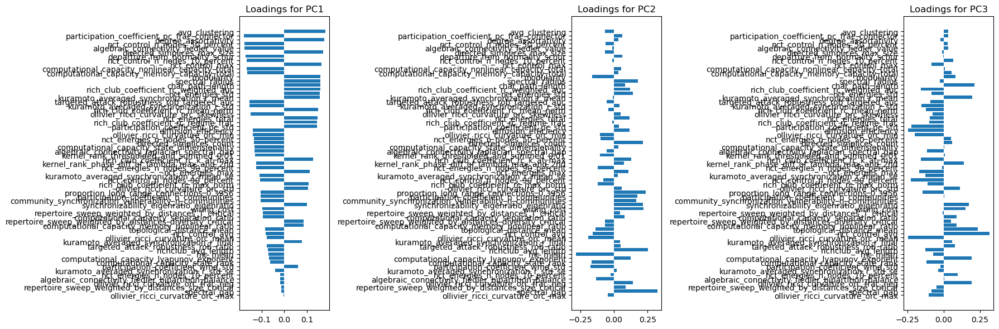

In [204]:

# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T[:, :]
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) # [::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


In [205]:
for m in metric_names[::-1]: 
    print(m)

avg_clustering
participation_coefficient_pc_frac_connector
degree_assortativity
nct_control_n_nodes_50_percent
algebraic_connectivity_fiedler_value
directed_simplices_max_size
departure_from_normality_schur
nct_control_n_nodes_10_percent
nct_control_max
computational_capacity_nonlinear_capacity_total
computational_capacity_memory_capacity_total
modularity
spectral_radius
char_path_length
rich_club_coefficient_rc_weighted_auc
nct_energies_std
kuramoto_averaged_synchronization_r_mean
targeted_attack_robustness_rob_targeted_auc
kuramoto_averaged_synchronization_r_std
rich_club_coefficient_rc_mean_norm
ollivier_ricci_curvature_orc_skewness
nct_energies_total
rich_club_coefficient_rc_regime_frac
participation_coefficient_pc_std
diffusion_efficiency
ollivier_ricci_curvature_orc_min
nct_energies_n_nodes_50_percent
directed_simplices_count
computational_capacity_state_dimensionality
algebraic_connectivity_laplacian_spectral_gap
kernel_rank_thresholded_and_summed_0.01
rich_club_coefficient_rc_k

In [ ]:
"avg_clustering",
"participation_coefficient_pc_frac_connector", 
# degree_assortativity
# nct_control_n_nodes_50_percent
"algebraic_connectivity_fiedler_value", 
# directed_simplices_max_size
# departure_from_normality_schur
# nct_control_n_nodes_10_percent
# nct_control_max
"computational_capacity_nonlinear_capacity_total", 
# computational_capacity_memory_capacity_total
# modularity
"spectral_radius", 
# char_path_length
# rich_club_coefficient_rc_weighted_auc
# nct_energies_std
# kuramoto_averaged_synchronization_r_mean
# targeted_attack_robustness_rob_targeted_auc
# kuramoto_averaged_synchronization_r_std
# rich_club_coefficient_rc_mean_norm
# ollivier_ricci_curvature_orc_skewness
# nct_energies_total
# rich_club_coefficient_rc_regime_frac
# participation_coefficient_pc_std
# diffusion_efficiency
# ollivier_ricci_curvature_orc_min
# nct_energies_n_nodes_50_percent
# directed_simplices_count
# computational_capacity_state_dimensionality
# algebraic_connectivity_laplacian_spectral_gap
# kernel_rank_thresholded_and_summed_0.01
# rich_club_coefficient_rc_k_at_max
# kernel_rank_phase_diff_of_lambda_max_and_2nd
# nct_energies_n_nodes_90_percent
# nct_energies_max
# kuramoto_averaged_synchronization_r_mean_se
# nct_control_n_nodes_90_percent
# rich_club_coefficient_rc_max_norm
# ollivier_ricci_curvature_orc_std
# proportion_long_range_connections_0.3956
# participation_coefficient_n_communities
# community_synchronization_vulnerability_n_communities
# synchronizability_eigenratio_eigenratio
# wiring_cost
# repertoire_sweep_weighted_by_distances_T_critical
# computational_capacity_separation_ratio
# repertoire_sweep_weighted_by_distances_diversity_critical
# computational_capacity_memory_nonlinear_ratio
# topological_distance_mean
# nct_control_avg
# ollivier_ricci_curvature_orc_mean
# kuramoto_averaged_synchronization_r_final
# targeted_attack_robustness_rob_ratio
# richclub_avg_length
# mc_mean
# computational_capacity_lyapunov_exponent
# computational_capacity_state_rank
# participation_coefficient_wmd_std
# kuramoto_averaged_synchronization_r_std_se
# nct_energies_n_nodes_10_percent
# algebraic_connectivity_fiedler_bipartition_balance
# ollivier_ricci_curvature_orc_frac_neg
# repertoire_sweep_weighted_by_distances_size_critical
# spectral_gap
# ollivier_ricci_curvature_orc_max

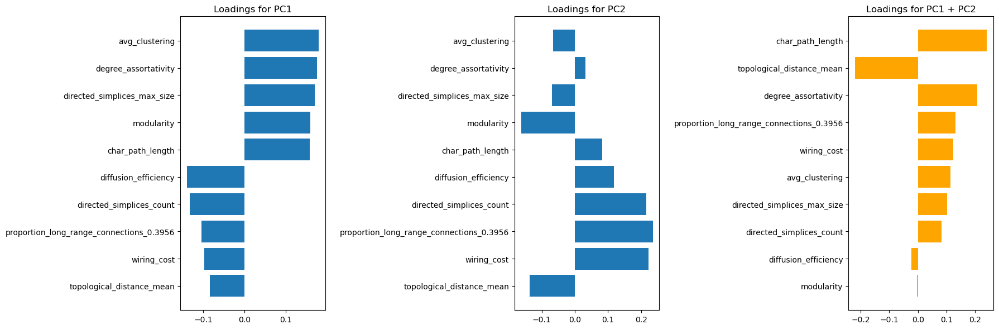

In [172]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(2):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")

# Plot 3: Addition of PC1 and PC2, ordered by magnitude of PC1+PC2
ordered_pc1_plus_pc2_indices = np.argsort(np.abs(loadings[:, 0] + loadings[:, 1])) #[::-1]
loadings = loadings[ordered_pc1_plus_pc2_indices]
metric_names = metric_names[ordered_pc1_plus_pc2_indices]
axs[2].barh(range(num_metrics), loadings[:, 0] + loadings[:, 1], color="orange")
axs[2].set_yticks(range(num_metrics))
axs[2].set_yticklabels(metric_names, rotation=0)
axs[2].set_title("Loadings for PC1 + PC2")

plt.tight_layout()
plt.show()

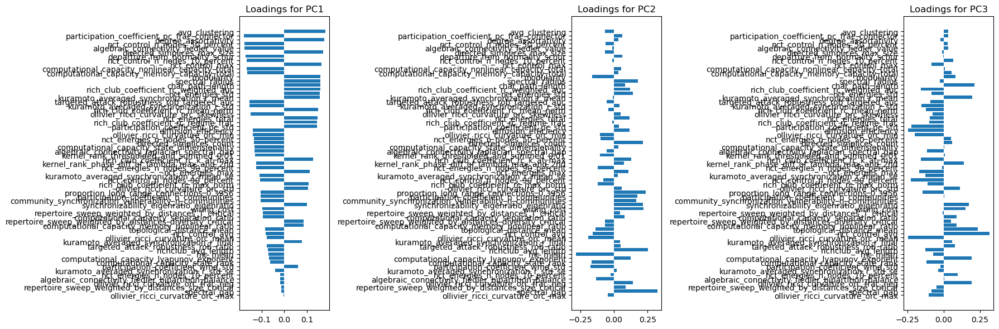

In [173]:
# Subplots of loadings for the first 3 principal components
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) #[::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()



In [174]:
# REPRESENTATIVES_FOR_GOALS = {
#     'mc_mean':                                          'Capacity (Memory)',
#     'modularity':                                       'Segregation',
#     'proportion_long_range_connections_0.3956':         'Wiring Economy',
#     'global_efficiency':                                'Integration',
#     'synchronizability_eigenratio_eigenratio':          'Synchronizability',
#     'kuramoto_synchronization_r_std':                   'Metastability',
#     'algebraic_connectivity_nx':                        'Robustness',
#     'computational_capacity_nonlinear_capacity_total':  'Capacity (Nonlinear)',
#     'repertoire_sweep_weighted_by_distances_diversity_critical': 'Repertoire Diversity',
#     'targeted_attack_robustness_rob_targeted_auc':      'Robustness (Targeted)',
# }

# rep_keys = list(REPRESENTATIVES_FOR_GOALS.keys())
# rep_labels = list(REPRESENTATIVES_FOR_GOALS.values())


In [175]:
huge_df_properties.columns

Index(['avg_clustering', 'modularity', 'degree_assortativity',
       'directed_simplices_count', 'directed_simplices_max_size',
       'char_path_length', 'diffusion_efficiency', 'topological_distance_mean',
       'wiring_cost', 'proportion_long_range_connections_0.3956',
       'richclub_avg_length', 'rich_club_coefficient_rc_max_norm',
       'rich_club_coefficient_rc_mean_norm',
       'rich_club_coefficient_rc_k_at_max',
       'rich_club_coefficient_rc_regime_frac',
       'rich_club_coefficient_rc_weighted_auc', 'spectral_radius',
       'spectral_gap', 'synchronizability_eigenratio_eigenratio',
       'kernel_rank_thresholded_and_summed_0.01',
       'kernel_rank_phase_diff_of_lambda_max_and_2nd',
       'algebraic_connectivity_fiedler_value',
       'algebraic_connectivity_laplacian_spectral_gap',
       'algebraic_connectivity_fiedler_bipartition_balance',
       'departure_from_normality_schur',
       'repertoire_sweep_weighted_by_distances_T_critical',
       'repertoire_

In [176]:
# ── Helper: spider plot ───────────────────────────────────────────────────────
def make_spider(ax, values, label, color, axis_labels, title=None):
    """Draw a single radar/spider plot on a polar axis."""
    n = len(axis_labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    vals = list(values) + [values[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)
    ax.set_thetagrids(np.degrees(angles[:-1]), axis_labels, fontsize=7)
    ax.tick_params(pad=6)
    if title:
        ax.set_title(title, fontsize=9, pad=14)


# ── Shared spider axis labels: predefined goal representatives ────────────────
# (Defined here so it's clear and not accidentally overriding the config import)
GOAL_REPRESENTATIVES = {
    "proportion_long_range_connections_0.3956":                 "Wiring\nEconomy",
    
    "modularity":                                               "Segregation",
    
    "computational_capacity_nonlinear_capacity_total":          "Capacity\n(Nonlinear)",
    "mc_mean":                                                  "Capacity\n(Memory)",
    # NCT control? 
    "nct_control_avg":                                          "Control\n(NCT)",
    
    # "global_efficiency":                                        "Integration",
    "char_path_length":                                         "Integration", # ???? \n(Path Length)",
    
    "targeted_attack_robustness_rob_targeted_auc":              "Robustness\n(Targeted)",
    "algebraic_connectivity_fiedler_value":                     "Robustness\n(lambda_2)", # lambda_2. # algebraic_connectivity_nx": 

    # "synchronizability_eigenratio_eigenratio":                  "Synchroniz-\nability",
    
    # "kuramoto_synchronization_r_std":                            "Metastability",
    "kuramoto_averaged_synchronization_r_std":                      "Metastability", # or "se"? 
    "repertoire_sweep_weighted_by_distances_diversity_critical": "Repertoire\nDiversity",
    
}
rep_keys   = list(GOAL_REPRESENTATIVES.keys())
rep_labels = list(GOAL_REPRESENTATIVES.values())
rep_idx    = [huge_df_properties.columns.get_loc(k) for k in rep_keys]

# ── Angles for spider (shared across all spider plots) ───────────────────────
n_axes   = len(rep_labels)
angles   = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles  += angles[:1]


# ── Corner point definitions ──────────────────────────────────────────────────
CORNER_COLORS = {
    "top_left":     "steelblue",
    "bottom_left":  "orange",
    "bottom_right": "forestgreen",
}

def find_corners(pca_result_2d):
    """Return a dict of corner name → row index within pca_result_2d."""
    return {
        "top_left":     int(np.argmax( pca_result_2d[:, 1])),
        "bottom_left":  int(np.argmax(-pca_result_2d[:, 0] - pca_result_2d[:, 1])),
        "bottom_right": int(np.argmax( pca_result_2d[:, 0] - pca_result_2d[:, 1])),
    }

Corner points (full dataset):
  top_left: idx=5626, PC1=11.82, PC2=15.63, dataset=hcp_schaefer_100_dataset_gnm
  bottom_left: idx=8358, PC1=-9.05, PC2=-1.13, dataset=hcp_schaefer_100_dataset_gnm
  bottom_right: idx=2031, PC1=9.36, PC2=-2.30, dataset=hcp_schaefer_100_dataset_gnm


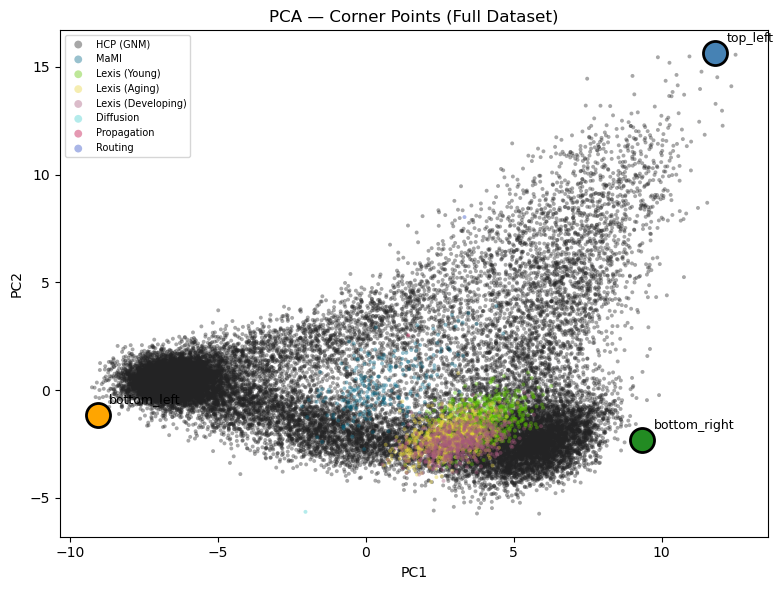

In [177]:
# ── Corners in the full selected-properties PCA space ────────────────────────
corners_full = find_corners(pca_result)

print("Corner points (full dataset):")
for name, idx in corners_full.items():
    ds = huge_df["dataset"].iloc[idx]
    print(f"  {name}: idx={idx}, PC1={pca_result[idx,0]:.2f}, PC2={pca_result[idx,1]:.2f}, dataset={ds}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for ds in huge_df["dataset"].unique():
    mask = (huge_df["dataset"] == ds).values
    ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
               c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
               alpha=0.4, s=8, edgecolors="none")
for name, idx in corners_full.items():
    ax.scatter(pca_result[idx, 0], pca_result[idx, 1],
               s=300, zorder=5, edgecolors="black", linewidths=2,
               color=CORNER_COLORS[name])
    ax.annotate(name, (pca_result[idx, 0], pca_result[idx, 1]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — Corner Points (Full Dataset)")
ax.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

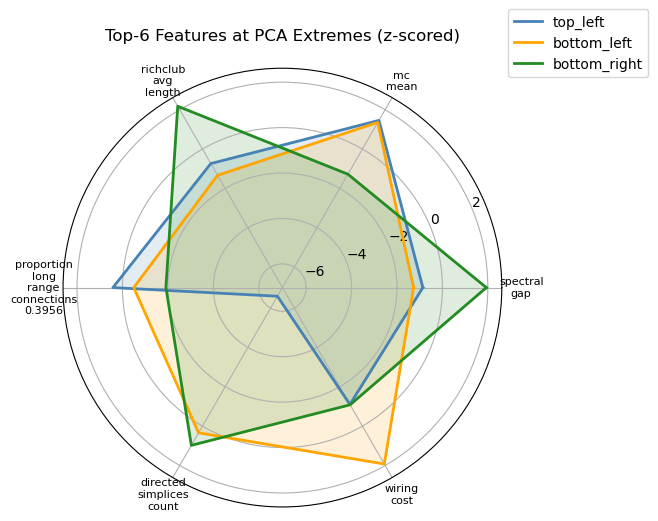

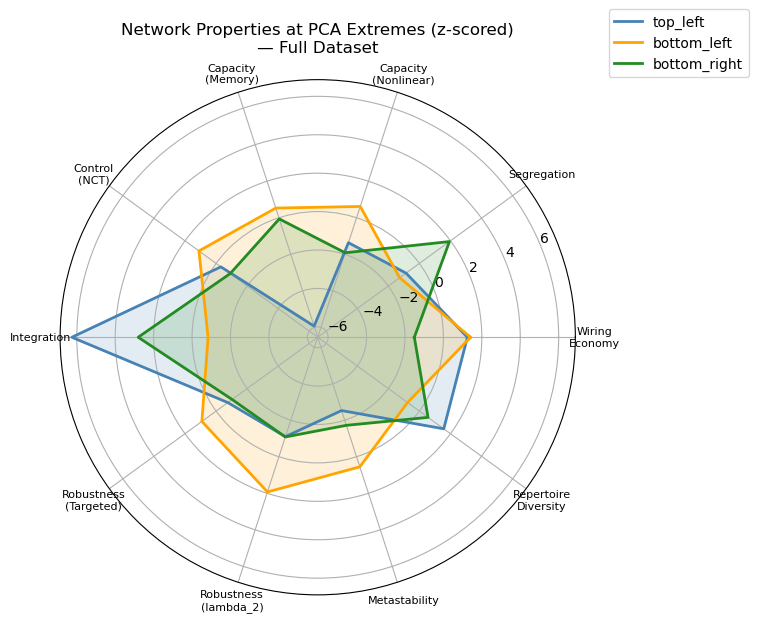

In [178]:
# ── Spider plot for the top-6 features by PC1+PC2 loading magnitude ──────────
top6_idx = np.argsort(np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2))[::-1][:6]
top6_names  = metric_names[top6_idx]
top6_labels = [n.replace("_", "\n") for n in top6_names]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name, idx in corners_full.items():
    vals = list(scaled_data[idx, top6_idx]) + [scaled_data[idx, top6_idx[0]]]
    a    = np.linspace(0, 2*np.pi, 6, endpoint=False).tolist() + [0]
    ax.plot(a, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
    ax.fill(a, vals, color=CORNER_COLORS[name], alpha=0.15)
ax.set_thetagrids(np.degrees(np.linspace(0, 2*np.pi, 6, endpoint=False)), top6_labels, fontsize=8)
ax.set_title("Top-6 Features at PCA Extremes (z-scored)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

# ── Spider plot using predefined goal representatives ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name, idx in corners_full.items():
    vals = list(scaled_data[idx, rep_idx]) + [scaled_data[idx, rep_idx[0]]]
    ax.plot(angles, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
    ax.fill(angles, vals, color=CORNER_COLORS[name], alpha=0.15)
ax.set_thetagrids(np.degrees(angles[:-1]), rep_labels, fontsize=8)
ax.set_title("Network Properties at PCA Extremes (z-scored)\n— Full Dataset", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

Corner points (no-GNM):
  top_left: filtered_idx=71, original_idx=25071, PC1=4.41, PC2=3.91, dataset=suarez_MaMI_dataset
  bottom_left: filtered_idx=177, original_idx=25177, PC1=-1.48, PC2=-2.40, dataset=suarez_MaMI_dataset
  bottom_right: filtered_idx=178, original_idx=25178, PC1=3.17, PC2=-0.07, dataset=suarez_MaMI_dataset


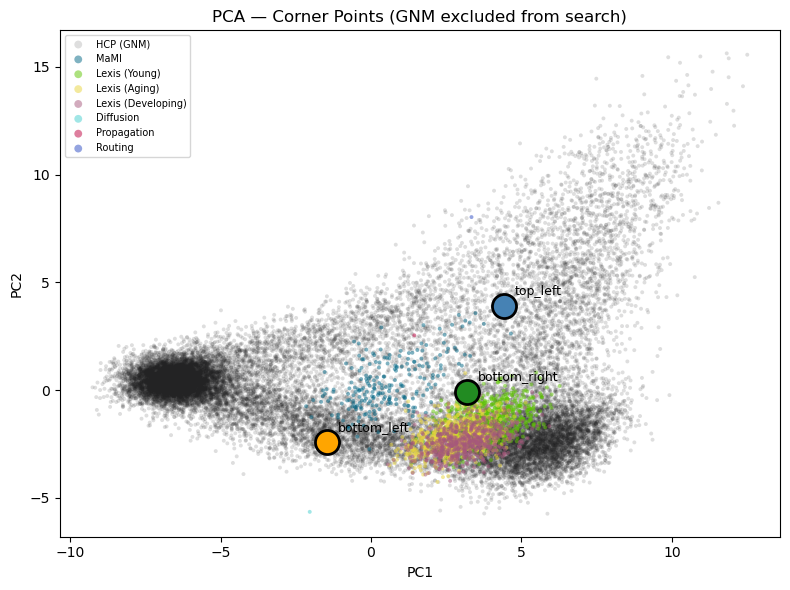

In [179]:
GNM_DATASET = "hcp_schaefer_100_dataset_gnm"

# Boolean mask & original indices of non-GNM rows
# no_gnm_mask          = (huge_df["dataset"] != GNM_DATASET).values
# no_gnm_original_idx  = np.where(no_gnm_mask)[0]        # positions in sel_scaled / pca_result
# mask = no_gnm_mask
# orig_idx = no_gnm_original_idx

# Only get datasets that are mami or hcp 
mask = (huge_df["dataset"] == "hcp_schaefer_100_dataset").values | (huge_df["dataset"] == "suarez_MaMI_dataset").values
orig_idx = np.where(mask)[0]        # positions in sel_scaled / pca_result

# PCA results restricted to non-GNM networks
pca_result_no_gnm = pca_result[mask]

# Find corners inside the filtered view (0-indexed within the subset)
corners_no_gnm_filtered = find_corners(pca_result_no_gnm)

# ── Remap to original row indices for sel_scaled ──────────────────────────────
# Without this step, e.g. filtered_idx=5 would incorrectly retrieve row 5 of
# sel_scaled (a GNM network), not the 5th non-GNM network.
corners_no_gnm = {
    name: int(orig_idx[filt_idx])
    for name, filt_idx in corners_no_gnm_filtered.items()
}

print("Corner points (no-GNM):")
for name, orig_idx in corners_no_gnm.items():
    ds = huge_df["dataset"].iloc[orig_idx]
    filt_idx = corners_no_gnm_filtered[name]
    print(f"  {name}: filtered_idx={filt_idx}, original_idx={orig_idx}, "
          f"PC1={pca_result[orig_idx,0]:.2f}, PC2={pca_result[orig_idx,1]:.2f}, dataset={ds}")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Background: all datasets (GNM faded)
for ds in huge_df["dataset"].unique():
    mask_ds = (huge_df["dataset"] == ds).values
    alpha = 0.15 if ds == GNM_DATASET else 0.5
    ax.scatter(pca_result[mask_ds, 0], pca_result[mask_ds, 1],
               c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
               alpha=alpha, s=8, edgecolors="none")

# Corner markers (using original indices so they are in the correct location)
for name, orig_idx in corners_no_gnm.items():
    ax.scatter(pca_result[orig_idx, 0], pca_result[orig_idx, 1],
               s=300, zorder=5, edgecolors="black", linewidths=2,
               color=CORNER_COLORS[name])
    ax.annotate(name, (pca_result[orig_idx, 0], pca_result[orig_idx, 1]),
                textcoords="offset points", xytext=(8, 8), fontsize=9)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — Corner Points (GNM excluded from search)")
ax.legend(markerscale=2, fontsize=7)
plt.tight_layout()
plt.show()

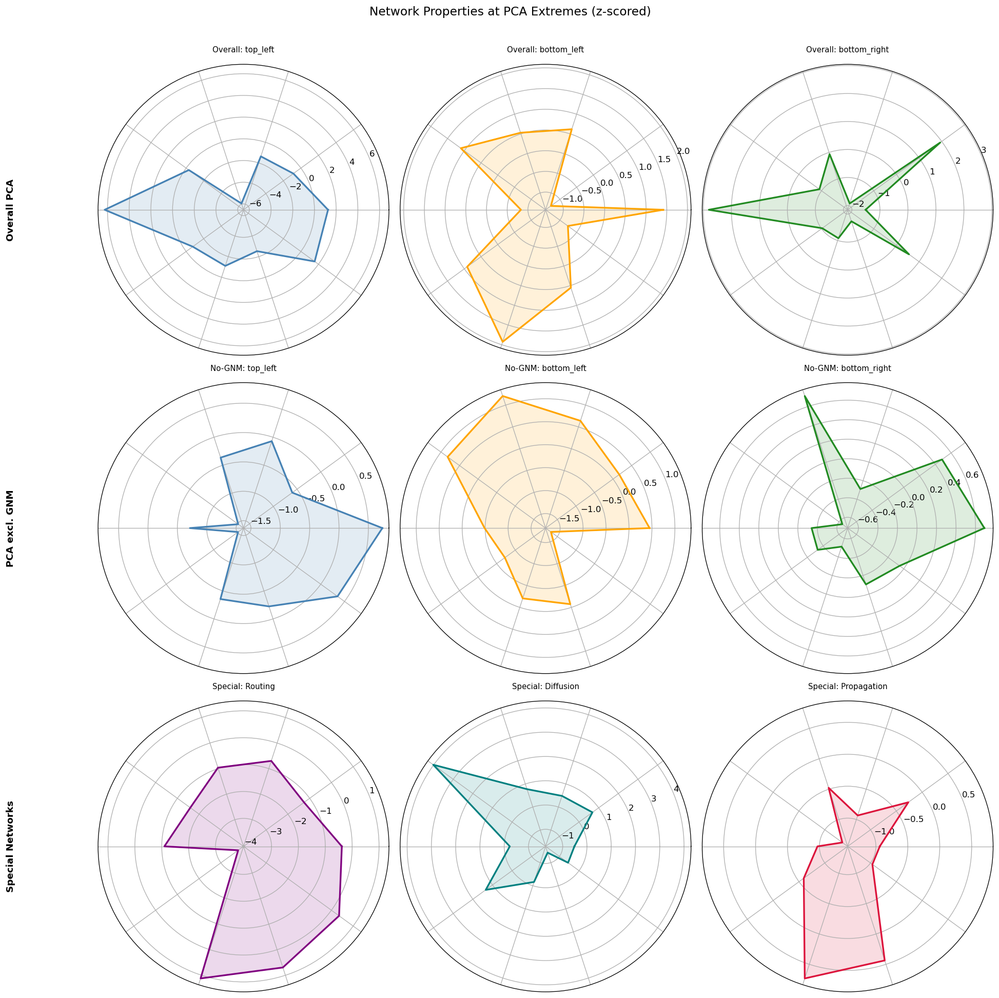

Saved: spider_multipanel.pdf


In [180]:
SPECIAL_DATASETS = {
    "kaysons_generated_networks_routing":     ("Routing",     "purple"),
    "kaysons_generated_networks_diffusion":   ("Diffusion",   "teal"),
    "kaysons_generated_networks_propagation": ("Propagation", "crimson"),
}

# Original row index for single-network datasets
special_indices = {
    ds: int(huge_df.index[huge_df["dataset"] == ds][0])
    for ds in SPECIAL_DATASETS
}

# ── Build 3 × 3 figure ────────────────────────────────────────────────────────
fig, axs = plt.subplots(3, 3, figsize=(16, 16), subplot_kw=dict(polar=True), dpi=120)

row_configs = [
    # (title prefix, corners_dict or special list, use_corners_colors)
    ("Overall",   list(corners_full.items()),    CORNER_COLORS),
    ("No-GNM",    list(corners_no_gnm.items()),  CORNER_COLORS),
    ("Special",   [(ds, idx) for ds, idx in special_indices.items()], None),
]

for row, (prefix, items, color_map) in enumerate(row_configs):
    for col, (key, orig_idx) in enumerate(items):
        ax = axs[row, col]

        if color_map is not None:
            color = color_map[key]
            label = key
        else:
            label, color = SPECIAL_DATASETS[key]

        vals = list(scaled_data[orig_idx, rep_idx]) + [scaled_data[orig_idx, rep_idx[0]]]
        make_spider(ax, vals[:-1], label, color, rep_labels,
                    title=f"{prefix}: {label}")
        # ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=7))
        ax.set_xticklabels([])  # Hide x-axis labels for cleaner look
        # ax.

# Row annotations
for row, label in enumerate(["Overall PCA", "PCA excl. GNM", "Special Networks"]):
    axs[row, 0].annotate(
        label, xy=(-0.3, 0.5), xycoords="axes fraction",
        fontsize=11, fontweight="bold", ha="center", va="center", rotation=90,
    )

fig.suptitle("Network Properties at PCA Extremes (z-scored)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(output_folder / "spider_multipanel.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: spider_multipanel.pdf")

In [181]:

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
all_vals = np.concatenate([scaled_data[idx, rep_idx] for idx in all_corner_indices])
# YLIM = (np.floor(all_vals.min()) - 0.5, np.ceil(all_vals.max()) + 0.5)
YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
# YLIM = [-2, 2] # 4] # 10]
# YLIM = (-3.5, 3.5)  # override to a clean symmetric range if preferred
RING_VALS = [-2, 0, 2] # -6, 2] # 
# RING_VALS = [-1 * YLIM[0], -0.5 * YLIM[0]] + [0] + [0.5 * YLIM[1], 1 * YLIM[1]] # , -2, -1, 1, 2, YLIM[1]] # 2, 2] # [-6, 4] # , 8, 12] # [-8, -6, -4, -2, 2, 4, 6, 8, 10] # [-4, -2, 2, 4]


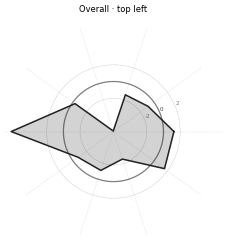

  Saved: spider_overall_top_left.pdf


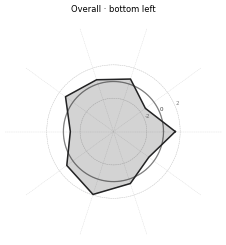

  Saved: spider_overall_bottom_left.pdf


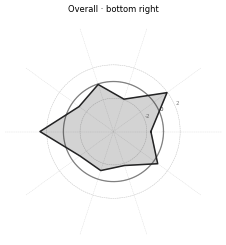

  Saved: spider_overall_bottom_right.pdf


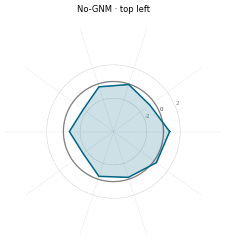

  Saved: spider_no_gnm_top_left.pdf


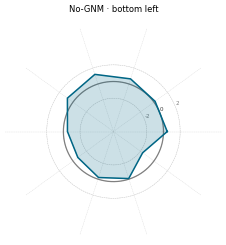

  Saved: spider_no_gnm_bottom_left.pdf


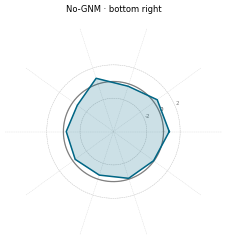

  Saved: spider_no_gnm_bottom_right.pdf


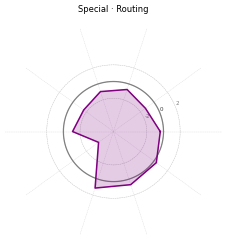

  Saved: spider_special_routing.pdf


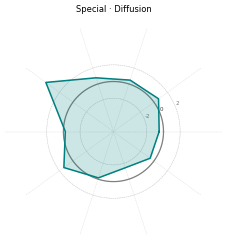

  Saved: spider_special_diffusion.pdf


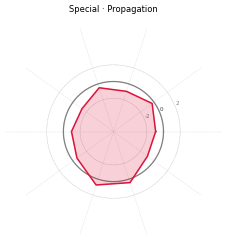

  Saved: spider_special_propagation.pdf
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_special_propagation.pdf


In [182]:
# ── Spider drawing function ────────────────────────────────────────────────────

def make_spider_standalone(values, label, color, feature_labels, title, ylim, filepath):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    # ── Limits & ticks ──
    ax.set_ylim(*ylim)
    ax.set_yticks(RING_VALS + [0]) # [-2, 0, 2])
    ax.set_yticklabels(RING_VALS + [0], fontsize=8, color="gray")

    # ── Remove outermost border ring ──
    ax.spines["polar"].set_visible(False)

    # ── Custom gridlines: draw manually so we can style zero differently ──
    ax.yaxis.grid(False)   # turn off auto y-gridlines
    ax.xaxis.grid(False)   # turn off auto x-gridlines (spokes we'll redraw)
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    for r_val in RING_VALS: # [-2, 2]:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    # Zero ring — heavier
    ax.plot(theta_ring, np.zeros(300),
            color="gray", linewidth=1.8, linestyle="-", zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

    # Spoke lines
    for angle in angles:
        ax.plot([angle, angle], YLIM, # [ylim[0], ylim[1]],
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)


    # ── Data ──
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

    # ── Feature labels (spokes) — no angle labels by default ──
    ax.set_thetagrids([])          # hide spoke degree labels; add manually below
    ax.set_xticklabels([])

    ax.set_title(title, pad=16) # , fontsize=10, pad=16, fontweight="bold")

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


# ── Build the list of 9 panels ────────────────────────────────────────────────

angles_for_legend = np.linspace(0, 2 * np.pi, len(rep_labels), endpoint=False).tolist()

panels = []

# First 6: Overall and No-GNM corners — color by *dataset* of that point
for corner_name, orig_idx in corners_full.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = scaled_data[orig_idx, rep_idx]
    panels.append((f"Overall · {corner_name.replace('_',' ')}", vals, color, f"spider_overall_{corner_name}.pdf"))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = scaled_data[orig_idx, rep_idx]
    panels.append((f"No-GNM · {corner_name.replace('_',' ')}", vals, color, f"spider_no_gnm_{corner_name}.pdf"))

# Last 3: Special single-network datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    vals = scaled_data[orig_idx, rep_idx]
    panels.append((f"Special · {label}", vals, color, f"spider_special_{label.lower()}.pdf"))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

for title, vals, color, fname in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        feature_labels=rep_labels,
        title=title,
        ylim=YLIM,
        filepath=output_folder / fname,
    )

print(output_folder / fname) 

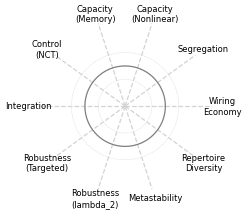

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_labels_only.pdf


In [183]:

def make_legend_plot(feature_labels, angles, filepath):
    """Empty radar with only the spoke labels visible."""
    n = len(feature_labels)
    angles_plot = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)
    ax.set_ylim(YLIM[0], YLIM[1]) # -3.5, 3.5)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    # ax.get_yticklabels(kwargs={"fontsize": 10})  # force generation of ytick labels for correct zorder

    # Draw spoke lines
    for angle in angles_plot:
        ax.plot([angle, angle], YLIM, # [-3.5, 3.5],
                color="lightgray", linewidth=1.8, # 2, # 0.5, 
                linestyle="--", zorder=0)
    # Zero ring
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    ax.plot(theta_ring, np.zeros(300), color="gray", linewidth=1.8, zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

    # Add spoke labels manually
    for angle, lbl in zip(angles_plot, feature_labels):
        x = np.degrees(angle)
        ax.set_thetagrids(np.degrees(angles_plot), feature_labels, fontsize=12)

    # ax.set_title("Legend / Labels", pad=16) # , fontsize=10, pad=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(filepath)


# ── Save the label-only plot ──────────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")


In [184]:
def draw_axis_group_arcs(ax, feature_labels, angles, arc_radius, groups):
    """
    Draw a bold arc just outside the plot connecting paired spokes.
    arc_radius: draw the arc at this r value (slightly beyond local_max).
    """
    theta_dense = np.linspace(0, 2 * np.pi, 1000)

    for label_a, label_b, color in groups:
        if label_a not in feature_labels or label_b not in feature_labels:
            continue
        i_a = feature_labels.index(label_a)
        i_b = feature_labels.index(label_b)

        angle_a = angles[i_a]
        angle_b = angles[i_b]

        # Always sweep the short way between the two spokes
        if angle_b < angle_a:
            angle_a, angle_b = angle_b, angle_a

        # Choose the shorter arc
        if angle_b - angle_a > np.pi:
            arc_angles = np.linspace(angle_b, angle_a + 2 * np.pi, 80)
        else:
            arc_angles = np.linspace(angle_a, angle_b, 80)

        arc_r = np.full_like(arc_angles, arc_radius)

        ax.plot(arc_angles, arc_r,
                color=color, linewidth=3.5, solid_capstyle="round",
                zorder=0, alpha=0.85)

        # Small dots at each endpoint to cap the arc neatly
        ax.scatter([arc_angles[0], arc_angles[-1]],
                   [arc_radius, arc_radius],
                   color=color, s=18, zorder=7, alpha=0.85)


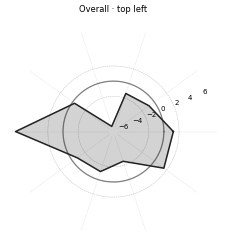

  Saved: spider_overall_top_left.pdf


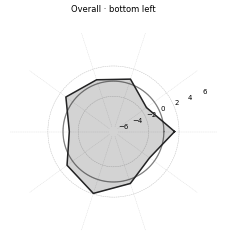

  Saved: spider_overall_bottom_left.pdf


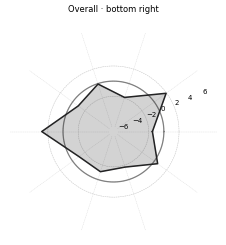

  Saved: spider_overall_bottom_right.pdf


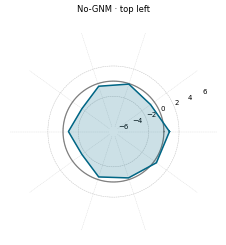

  Saved: spider_no_gnm_top_left.pdf


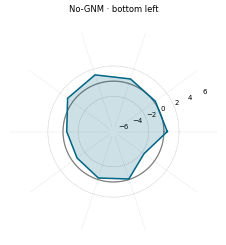

  Saved: spider_no_gnm_bottom_left.pdf


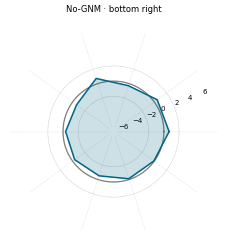

  Saved: spider_no_gnm_bottom_right.pdf


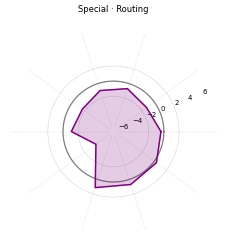

  Saved: spider_special_routing.pdf


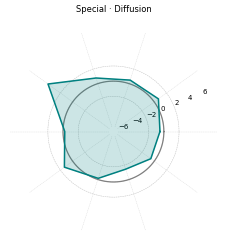

  Saved: spider_special_diffusion.pdf


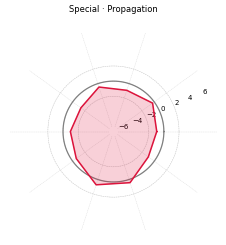

  Saved: spider_special_propagation.pdf


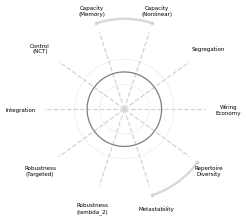

  Saved: spider_labels_only.pdf

Done — 10 files saved.
Files are in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis


In [185]:
# ── Global y-range (shared across all plots) ──────────────────────────────────

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
all_vals = np.concatenate([scaled_data[idx, rep_idx] for idx in all_corner_indices])
# YLIM = (np.floor(all_vals.min()) - 0.5, np.ceil(all_vals.max()) + 0.5)
YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
# YLIM = [-2, 2] # 4] # 10]
# YLIM = (-3.5, 3.5)  # override to a clean symmetric range if preferred
RING_VALS = [-2, 0, 2] # -6, 2] # 
# RING_VALS = [-1 * YLIM[0], -0.5 * YLIM[0]] + [0] + [0.5 * YLIM[1], 1 * YLIM[1]] # , -2, -1, 1, 2, YLIM[1]] # 2, 2] # [-6, 4] # , 8, 12] # [-8, -6, -4, -2, 2, 4, 6, 8, 10] # [-4, -2, 2, 4]

AXIS_GROUPS = [
    ("Capacity\n(Nonlinear)", "Capacity\n(Memory)",     "lightgray"), # "#E07B39"),  # orange
    ("Robustness\n(Targeted)", "Robustness",              "lightgray"),  # "#5B8DB8"),  # blue
    ("Metastability",          "Repertoire\nDiversity",   "lightgray"),  # "#6AAB6A"),  # green
]

# ── Spider drawing function ────────────────────────────────────────────────────

def make_spider_standalone(values, label, color, feature_labels, title, ylim, filepath):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    # ── Limits & ticks ──
    # ax.set_ylim(*ylim)
    # ax.set_yticks(RING_VALS + [0]) # [-2, 0, 2])
    # ax.set_yticklabels(RING_VALS + [0], fontsize=8, color="gray")
    # ax.set_yticklabels(fontsize=8, color="gray")

    # ── Remove outermost border ring ──
    ax.spines["polar"].set_visible(False)

    # ── Custom gridlines: draw manually so we can style zero differently ──
    ax.yaxis.grid(False)   # turn off auto y-gridlines
    ax.xaxis.grid(False)   # turn off auto x-gridlines (spokes we'll redraw)
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    for r_val in RING_VALS: # [-2, 2]:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    # Zero ring — heavier
    ax.plot(theta_ring, np.zeros(300),
            color="gray", linewidth=1.8, linestyle="-", zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

    # Spoke lines
    for angle in angles:
        ax.plot([angle, angle], YLIM, # [ylim[0], ylim[1]],
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)


    # ── Data ──
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

    # ── Feature labels (spokes) — no angle labels by default ──
    ax.set_thetagrids([])          # hide spoke degree labels; add manually below
    ax.set_xticklabels([])

    ax.set_title(title, pad=16) # , fontsize=10, pad=16, fontweight="bold")

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


def make_legend_plot(feature_labels, angles, filepath):
    """Empty radar with only the spoke labels visible."""
    n = len(feature_labels)
    angles_plot = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)
    ax.set_ylim(YLIM[0], YLIM[1]) # -3.5, 3.5)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    # Draw spoke lines
    for angle in angles_plot:
        ax.plot([angle, angle], YLIM, # [-3.5, 3.5],
                color="lightgray", linewidth=1.8, # 2, # 0.5, 
                linestyle="--", zorder=0)
        
    # ── Group arcs just outside the outermost ring ──
    local_min, local_max = YLIM[0], YLIM[1]
    arc_r = local_max + (local_max - local_min) * 0.12
    draw_axis_group_arcs(ax, list(feature_labels), angles, arc_r, AXIS_GROUPS)
    # Expand ylim slightly so the arc isn't clipped
    ax.set_ylim(local_min, arc_r + (local_max - local_min) * 0.05)

    # Zero ring
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    ax.plot(theta_ring, np.zeros(300), color="gray", linewidth=1.8, zorder=1)
    # Other rings: 
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
        

    # Add spoke labels manually
    for angle, lbl in zip(angles_plot, feature_labels):
        x = np.degrees(angle)
        ax.set_thetagrids(np.degrees(angles_plot), feature_labels, fontsize=8)
        

    # ax.set_title("Legend / Labels", pad=16) # , fontsize=10, pad=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


# ── Build the list of 9 panels ────────────────────────────────────────────────

angles_for_legend = np.linspace(0, 2 * np.pi, len(rep_labels), endpoint=False).tolist()

panels = []

# First 6: Overall and No-GNM corners — color by *dataset* of that point
for corner_name, orig_idx in corners_full.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = scaled_data[orig_idx, rep_idx]
    panels.append((f"Overall · {corner_name.replace('_',' ')}", vals, color, f"spider_overall_{corner_name}.pdf"))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    vals  = scaled_data[orig_idx, rep_idx]
    panels.append((f"No-GNM · {corner_name.replace('_',' ')}", vals, color, f"spider_no_gnm_{corner_name}.pdf"))

# Last 3: Special single-network datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    vals = scaled_data[orig_idx, rep_idx]
    panels.append((f"Special · {label}", vals, color, f"spider_special_{label.lower()}.pdf"))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

for title, vals, color, fname in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        feature_labels=rep_labels,
        title=title,
        ylim=YLIM,
        filepath=output_folder / fname,
    )

# ── Save the label-only plot ──────────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")

print("\nDone — 10 files saved.")
print(f"Files are in: {output_folder.resolve()}")

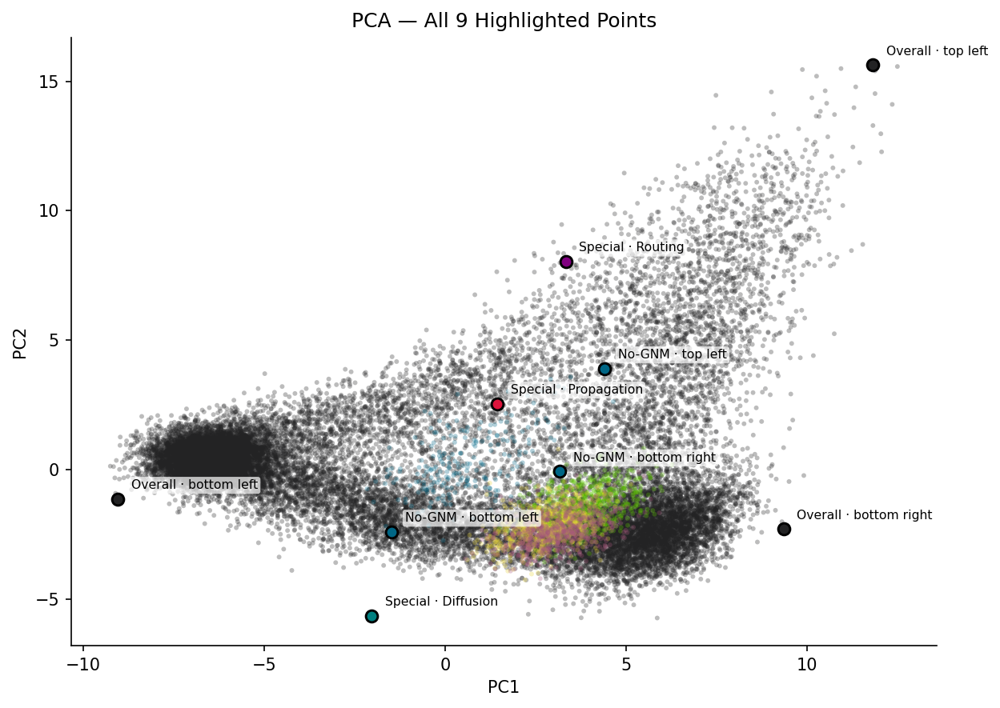

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_highlighted_9points.pdf


In [186]:
# ── Build color + label lookup for all 9 highlighted points ──────────────────
highlighted = {}

# First 6: corners_full and corners_no_gnm — same color logic as spider plots
for corner_name, orig_idx in corners_full.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"Overall · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
                          "source": "full"}

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"No-GNM · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
                          "source": "no_gnm"}

# Last 3: special datasets
for ds_key, orig_idx in special_indices.items():
    sp_label, color = SPECIAL_DATASETS[ds_key]
    label = f"Special · {sp_label}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
                          "source": "special"}

# ── PCA scatter — background points ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for ds in huge_df["dataset"].unique():
    mask = (huge_df["dataset"] == ds).values
    ax.scatter(
        pca_result[mask, 0], pca_result[mask, 1],
        c=COLOR_SCHEME[ds], label=LABEL_MAP.get(ds, ds),
        alpha=0.3, s=8, edgecolors="none", zorder=1,
    )

# ── Highlighted points ────────────────────────────────────────────────────────

marker_legend = {"full": ("o", "Overall corner"), "no_gnm": ("s", "No-GNM corner"), "special": ("^", "Special network")}

for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    # marker = info["marker"]
    ax.scatter(
        pca_result[idx, 0], pca_result[idx, 1],
        color=color, # marker=marker,
        s=50, # 220, 
        zorder=6,
        edgecolors="black", linewidths=1.4,
    )
    
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points.pdf", dpi=150, bbox_inches="tight")



for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    ax.annotate(
        label,
        (pca_result[idx, 0], pca_result[idx, 1]),
        textcoords="offset points", xytext=(8, 6),
        fontsize=7.5, zorder=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )


plt.show()
print(output_folder / "pca_highlighted_9points.pdf")

In [187]:
sel_df_label = huge_df
sel_pca_result = pca_result
sel_scaled = scaled_data

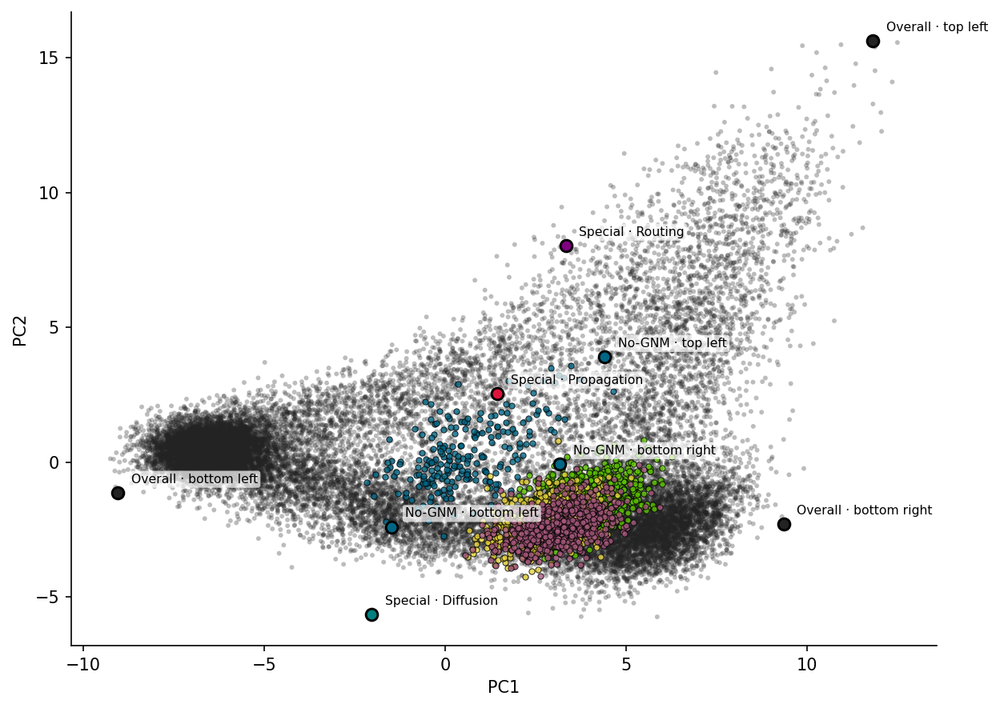

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_highlighted_9points.pdf


In [188]:
# ── Build color + label lookup for all 9 highlighted points ──────────────────
highlighted = {}

# First 6: corners_full and corners_no_gnm — same color logic as spider plots
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"Overall · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "o", 
                          "source": "full"}

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    label = f"No-GNM · {corner_name.replace('_', ' ')}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "s", 
                          "source": "no_gnm"}

# Last 3: special datasets
for ds_key, orig_idx in special_indices.items():
    sp_label, color = SPECIAL_DATASETS[ds_key]
    label = f"Special · {sp_label}"
    highlighted[label] = {"idx": orig_idx, "color": color, # "marker": "^", 
                          "source": "special"}

# ── PCA scatter — background points ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for ds in sel_df_label["dataset"].unique():
    mask = (sel_df_label["dataset"] == ds).values
    ax.scatter(
        sel_pca_result[mask, 0], sel_pca_result[mask, 1],
        c=COLOR_SCHEME[ds], 
        label=LABEL_MAP.get(ds, ds),
        alpha=0.3 if ds == GNM_DATASET else 0.8, 
        s=8 if ds == GNM_DATASET else 12, 
        edgecolors="none" if ds == GNM_DATASET else "black", 
        linewidths=0 if ds == GNM_DATASET else 0.5,
        zorder=1,
    )

# ── Highlighted points ────────────────────────────────────────────────────────

marker_legend = {"full": ("o", "Overall corner"), 
                 "no_gnm": ("s", "No-GNM corner"), 
                 "special": ("^", "Special network")}

for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    # marker = info["marker"]
    ax.scatter(
        sel_pca_result[idx, 0], sel_pca_result[idx, 1],
        color=color, # marker=marker,
        s=50, # 220, 
        zorder=6,
        edgecolors="black", 
        linewidths=1.4,
    )
    
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel("PC1") # , fontsize=10)
ax.set_ylabel("PC2") # , fontsize=10)
# ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(output_folder / "pca_highlighted_9points.pdf", dpi=150, bbox_inches="tight")



for label, info in highlighted.items():
    idx    = info["idx"]
    color  = info["color"]
    ax.annotate(
        label,
        (sel_pca_result[idx, 0], sel_pca_result[idx, 1]),
        textcoords="offset points", xytext=(8, 6),
        fontsize=7.5, zorder=7,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )


plt.show()
print(output_folder / "pca_highlighted_9points.pdf")

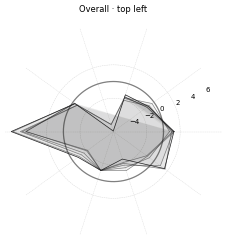

  Saved: spider_overall_top_left.pdf


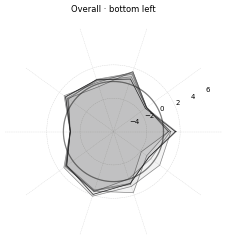

  Saved: spider_overall_bottom_left.pdf


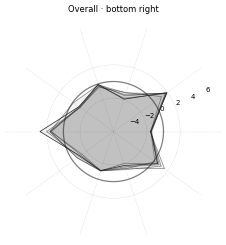

  Saved: spider_overall_bottom_right.pdf


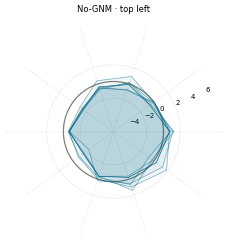

  Saved: spider_no_gnm_top_left.pdf


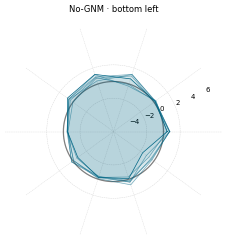

  Saved: spider_no_gnm_bottom_left.pdf


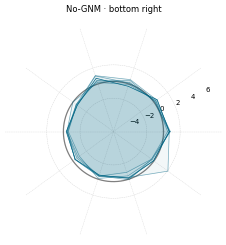

  Saved: spider_no_gnm_bottom_right.pdf


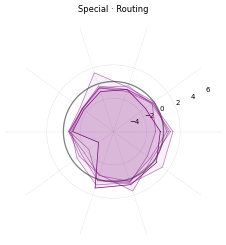

  Saved: spider_special_routing.pdf


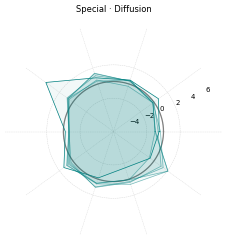

  Saved: spider_special_diffusion.pdf


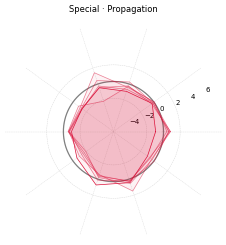

  Saved: spider_special_propagation.pdf


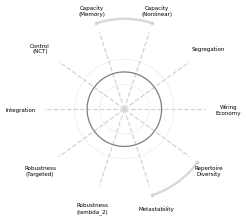

  Saved: spider_labels_only.pdf

Done — 10 files saved.


In [189]:
from sklearn.metrics import pairwise_distances

# ── Compute 5 nearest neighbours for each panel point ────────────────────────
# Use the full PCA embedding (all 10 components) for distance

def get_neighbours(orig_idx, pca_result, n=5, exclude_gnm=False, df_label=None, gnm_name=None):
    """Return indices of the n closest rows in pca_result to orig_idx."""
    dists = pairwise_distances(pca_result[orig_idx:orig_idx+1], pca_result)[0]
    dists[orig_idx] = np.inf  # exclude self
    if exclude_gnm and df_label is not None:
        gnm_mask = (df_label["dataset"] == gnm_name).values
        dists[gnm_mask] = np.inf
    return np.argsort(dists)[:n].tolist()


# ── Modified spider drawing function with neighbours ─────────────────────────

def make_spider_standalone(values, label, color, feature_labels, title, ylim,
                           filepath, neighbour_vals_list=None):
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

    ax.set_ylim(*ylim)
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    theta_ring = np.linspace(0, 2 * np.pi, 300)

    # ── Gridlines ──
    for r_val in RING_VALS:
        ax.plot(theta_ring, np.full(300, r_val),
                color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
    ax.plot(theta_ring, np.zeros(300),
            color="gray", linewidth=1.8, linestyle="-", zorder=1)
    for angle in angles:
        ax.plot([angle, angle], ylim,
                color="lightgray", linewidth=0.5, linestyle="--", zorder=0)

    # # ── Neighbour lines (faded, thin, same color) ──
    # if neighbour_vals_list is not None:
    #     for nb_vals in neighbour_vals_list:
    #         nb_closed = list(nb_vals) + [nb_vals[0]]
    #         ax.plot(angles_closed, nb_closed,
    #                 color=color, linewidth=0.6, alpha=0.25, zorder=3)
    #         ax.fill(angles_closed, nb_closed,
    #                 color=color, alpha=0.04, zorder=2)

    # # ── Main data (on top) ──
    # ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
    # ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)


    # ── Neighbour lines and main line all same style --- # (faded, thin, same color) ──
    alpha_fill = 0.05
    linewidth = 1
    zorder = 3
    
    if neighbour_vals_list is not None:
        for nb_vals in neighbour_vals_list:
            nb_closed = list(nb_vals) + [nb_vals[0]]
            ax.plot(angles_closed, nb_closed,
                    color=color, linewidth=linewidth, alpha=alpha, zorder=zorder+1)
            ax.fill(angles_closed, nb_closed,
                    color=color, alpha=alpha_fill, zorder=zorder)

    # ── Main data (on top) ──
    ax.plot(angles_closed, vals_closed, color=color, linewidth=linewidth, zorder=zorder+1)
    ax.fill(angles_closed, vals_closed, color=color, alpha=alpha_fill, zorder=zorder)



    ax.set_thetagrids([])
    ax.set_xticklabels([])
    ax.set_title(title, pad=16)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {filepath.name}")


# ── Rebuild panels list with neighbour data ───────────────────────────────────

panels = []

# First 6: Overall and No-GNM corners
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Overall · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_overall_{corner_name}.pdf",
        nb_vals,
    ))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    # Exclude GNM from neighbour search too, since we're in the no-GNM regime
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5,
                            exclude_gnm=True, df_label=sel_df_label, gnm_name=GNM_DATASET)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"No-GNM · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_no_gnm_{corner_name}.pdf",
        nb_vals,
    ))

# Last 3: Special datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Special · {label}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_special_{label.lower()}.pdf",
        nb_vals,
    ))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

for title, vals, color, fname, nb_vals in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        feature_labels=rep_labels,
        title=title,
        ylim=YLIM,
        filepath=output_folder / fname,
        neighbour_vals_list=nb_vals,
    )

# ── Label-only plot (unchanged) ───────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")

print("\nDone — 10 files saved.")

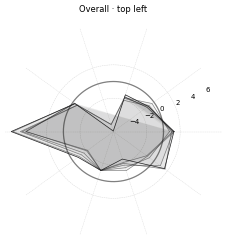

  Saved: spider_overall_top_left.pdf


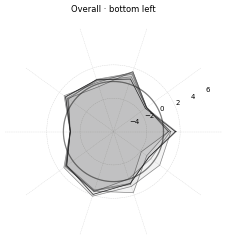

  Saved: spider_overall_bottom_left.pdf


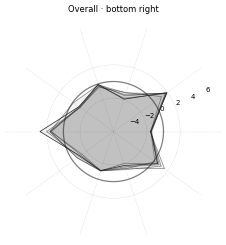

  Saved: spider_overall_bottom_right.pdf


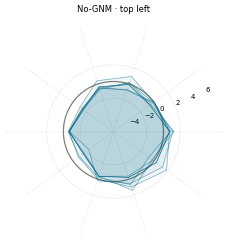

  Saved: spider_no_gnm_top_left.pdf


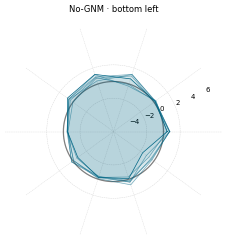

  Saved: spider_no_gnm_bottom_left.pdf


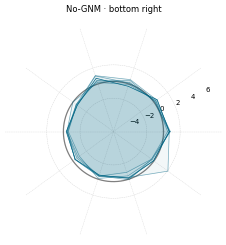

  Saved: spider_no_gnm_bottom_right.pdf


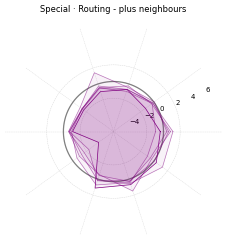

  Saved: spider_special_routing.pdf


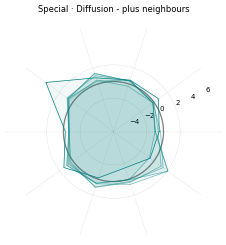

  Saved: spider_special_diffusion.pdf


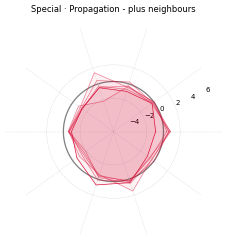

  Saved: spider_special_propagation.pdf


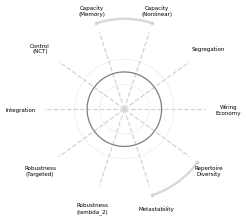

  Saved: spider_labels_only.pdf
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spider_special_propagation.pdf


In [190]:

# ── Rebuild panels list with neighbour data ───────────────────────────────────

panels = []

# First 6: Overall and No-GNM corners
for corner_name, orig_idx in corners_full.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Overall · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_overall_{corner_name}.pdf",
        nb_vals,
    ))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = sel_df_label["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    # Exclude GNM from neighbour search too, since we're in the no-GNM regime
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5,
                            exclude_gnm=True, df_label=sel_df_label, gnm_name=GNM_DATASET)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"No-GNM · {corner_name.replace('_', ' ')}",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_no_gnm_{corner_name}.pdf",
        nb_vals,
    ))

# Last 3: Special datasets
for ds_key, orig_idx in special_indices.items():
    label, color = SPECIAL_DATASETS[ds_key]
    nb_idx = get_neighbours(orig_idx, sel_pca_result, n=5)
    nb_vals = [sel_scaled[i, rep_idx] for i in nb_idx]
    panels.append((
        f"Special · {label} - plus neighbours",
        sel_scaled[orig_idx, rep_idx], color,
        f"spider_special_{label.lower()}.pdf",
        nb_vals,
    ))

# ── Save all 9 plots ──────────────────────────────────────────────────────────

# for title, vals, color, fname, nb_vals in panels:
#     make_spider_standalone(
#         values=vals,
#         label=title,
#         color=color,
#         feature_labels=rep_labels,
#         title=title,
#         ylim=YLIM,
#         filepath=output_folder / fname,
#         neighbour_vals_list=nb_vals,
#     )
for title, vals, color, fname, nb_vals in panels:
    make_spider_standalone(
        values=vals,
        label=title,
        color=color,
        ylim=YLIM,
        feature_labels=rep_labels,
        title=title,
        filepath=output_folder / fname,
        neighbour_vals_list=nb_vals,
    )
# ── Label-only plot (unchanged) ───────────────────────────────────────────────

make_legend_plot(rep_labels, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf")

print(output_folder / fname)

In [191]:
dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].keys()

Index(['transitivity', 'avg_clustering', 'modularity', 'degree_gini',
       'degree_assortativity', 'omega', 'structural_complexity',
       'directed_simplices_count', 'directed_simplices_max_size', 'eta',
       'gamma', 'char_path_length', 'global_efficiency',
       'diffusion_efficiency', 'propagation_efficiency', 'avg_communicability',
       'topological_distance_mean', 'topological_distance_std',
       'avg_edge_distance', 'wiring_cost',
       'proportion_long_range_connections_0.1',
       'proportion_long_range_connections_0.3',
       'proportion_long_range_connections_0.3956',
       'proportion_long_range_connections_0.5', 'richclub_n_edges',
       'richclub_avg_length', 'rich_club_coefficient_rc_max_norm',
       'rich_club_coefficient_rc_mean_norm',
       'rich_club_coefficient_rc_k_at_max',
       'rich_club_coefficient_rc_regime_frac',
       'rich_club_coefficient_rc_weighted_auc', 'spectral_radius',
       'spectral_gap', 'synchronizability_eigenratio_eigenratio

KeyboardInterrupt: 

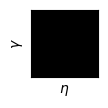

In [192]:
from utils import get_colorchannels_from_eta_gamma

combined_colors = get_colorchannels_from_eta_gamma(huge_df) 

plt.figure(figsize=viz.cm_to_inch((3,3)))
plt.scatter(huge_df["eta"], huge_df["gamma"], c=combined_colors, s=2, edgecolors="none")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")
plt.xticks([])
plt.yticks([])
plt.xlim(-8,3)
plt.ylim(-0.1,1)
plt.tight_layout()
plt.savefig(output_folder / "eta_gamma_color_mapping.pdf", dpi=150, bbox_inches="tight")
print(output_folder / "eta_gamma_color_mapping.pdf")

# Taxonomies 

In [ ]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
taxonomy = "order" # phylogenetic_group" # "order" 

GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]
# info_mami = info_mami[info_mami[taxonomy].isin(GROUPS_TO_INCLUDE)]

# info_mami["tax_color"] = info_mami[taxonomy].astype("category").cat.codes

df_mami = pd.concat([sel_df_label[sel_df_label["dataset"] == "suarez_MaMI_dataset"].reset_index(), info_mami], axis=1) # , left_index=True, right_on=True) # "animal_name")

names = df_mami[taxonomy].unique() # ["tax_color"]
color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))
color_dict = {name: color_map(i) for i, name in enumerate(names)}

df_mami["tax_color"] = df_mami[taxonomy].map(color_dict)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_87575/474977728.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_87575/1666987118.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],


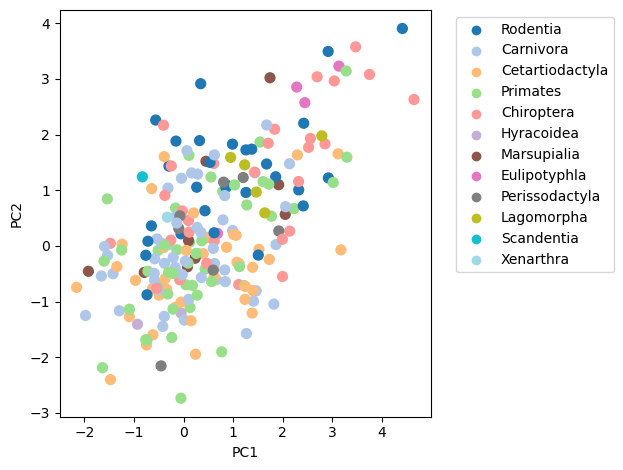

In [ ]:
plt.scatter(sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 0], 
            sel_pca_result[sel_df_label["dataset"] == "suarez_MaMI_dataset", 1], 
            c=df_mami["tax_color"], 
            s=50)

# Faking the legend
for name in df_mami[taxonomy].unique(): # GROUPS_TO_INCLUDE: # color_dict:
    plt.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                    c=color_dict[name],
                    label=str(name))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # , fontsize=3, frameon=False, labelspacing=1, title='City Area') phylogenetic_group

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

In [ ]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
taxonomy = "order" 

GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]
# info_mami = info_mami[info_mami[taxonomy].isin(GROUPS_TO_INCLUDE)]

# info_mami["tax_color"] = info_mami[taxonomy].astype("category").cat.codes

df_mami = pd.concat([sel_df_label[sel_df_label["dataset"] == "suarez_MaMI_dataset"].reset_index(), info_mami], axis=1) # , left_index=True, right_on=True) # "animal_name")

names = df_mami[taxonomy].unique() # ["tax_color"]
color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))
color_dict = {name: color_map(i) for i, name in enumerate(names)}

df_mami["tax_color"] = df_mami[taxonomy].map(color_dict)



/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_87575/463988841.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(names)) # "RdYlGn_r", len(names))


In [ ]:
from sklearn.metrics import pairwise_distances
from scipy.stats import f_oneway
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ── Extract the relevant PCA coordinates + labels ─────────────────────────────

mami_mask  = (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
tax_mask   = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE).values
combined   = mami_mask.copy()
combined[mami_mask] = tax_mask          # both conditions

X      = sel_pca_result[combined, :2]   # PC1 + PC2 only
labels = df_mami[tax_mask][taxonomy].values

# ── Test 1: PERMANOVA (permutation-based MANOVA on distances) ─────────────────
# "Are the groups more separated than random chance?"

from sklearn.utils import shuffle

def permanova(X, labels, n_permutations=999):
    def f_stat(X, labels):
        groups  = [X[labels == g] for g in np.unique(labels)]
        grand_m = X.mean(axis=0)
        ss_between = sum(len(g) * ((g.mean(0) - grand_m)**2).sum() for g in groups)
        ss_within  = sum(((g - g.mean(0))**2).sum() for g in groups)
        k, n = len(groups), len(X)
        return (ss_between / (k-1)) / (ss_within / (n-k))

    observed = f_stat(X, labels)
    null_dist = [f_stat(X, shuffle(labels)) for _ in range(n_permutations)]
    p = (np.sum(np.array(null_dist) >= observed) + 1) / (n_permutations + 1)
    return observed, p

f_obs, p_perm = permanova(X, labels)
print(f"PERMANOVA  →  F = {f_obs:.3f},  p = {p_perm:.4f}")

# ── Test 2: Per-axis ANOVA ─────────────────────────────────────────────────────
# "Does any single PC axis separate the groups?"

groups_pc1 = [X[labels == g, 0] for g in np.unique(labels)]
groups_pc2 = [X[labels == g, 1] for g in np.unique(labels)]
f1, p1 = f_oneway(*groups_pc1)
f2, p2 = f_oneway(*groups_pc2)
print(f"ANOVA PC1  →  F = {f1:.3f},  p = {p1:.4f}")
print(f"ANOVA PC2  →  F = {f2:.3f},  p = {p2:.4f}")

# ── Test 3: LDA cross-validated accuracy ──────────────────────────────────────
# "Can we predict group membership better than chance?"

from sklearn.model_selection import cross_val_score
lda      = LinearDiscriminantAnalysis()
cv_score = cross_val_score(lda, X, labels, cv=5, scoring="accuracy").mean()
chance   = 1 / len(np.unique(labels))
print(f"LDA 5-fold CV accuracy = {cv_score:.3f}  (chance = {chance:.3f})")

PERMANOVA  →  F = 9.243,  p = 0.0010
ANOVA PC1  →  F = 2.991,  p = 0.0327
ANOVA PC2  →  F = 17.300,  p = 0.0000
LDA 5-fold CV accuracy = 0.368  (chance = 0.250)


# Ages 

In [ ]:
for dataset_name, d in dict_with_all_datasets.items():
    

    if "lexis_data_" in dataset_name:
    
            print(dataset_name)
            ages = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/{dataset_name}/04_further_info/00_ages.npy")
            # Turn dict_with_all_datasets["lexis_data_aging"].index into a mask
            
            mask = np.zeros_like(ages)
            mask[dict_with_all_datasets[dataset_name].index] = 1
            mask = mask.astype(bool)
            
            # add an age column by index to the main dataframe
            dict_with_all_datasets[dataset_name]["age"] = ages[mask]
        

lexis_data_young
lexis_data_aging
lexis_data_developing


In [ ]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name in ordered_dataset_names: 
    df = dict_with_all_datasets[dataset_name]
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology" or dataset_name == "hcp_schaefer_100_dataset": 
        print(" ---> skipped")
        continue
    huge_df = pd.concat([huge_df, df], ignore_index=True)
    

hcp_schaefer_100_dataset_gnm 25000
suarez_MaMI_dataset 224
lexis_data_young 703
lexis_data_aging 687
lexis_data_developing 629
kaysons_generated_networks_diffusion 1
kaysons_generated_networks_propagation 1
kaysons_generated_networks_routing 1


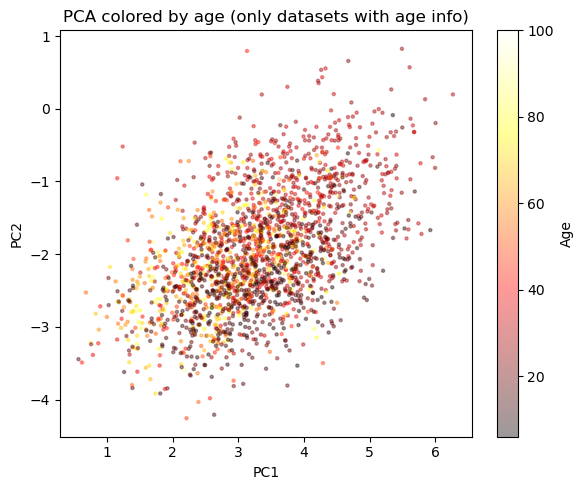

In [ ]:
# Look at huge_df where age is defined. Then plot the pca space colored by age.
huge_df_age = huge_df[huge_df["age"].notna()]
plt.figure(figsize=(6,5))
plt.scatter(sel_pca_result[huge_df["age"].notna(), 0], sel_pca_result[huge_df["age"].notna(), 1],
            c=huge_df_age["age"], 
            cmap="hot", # viridis", 
            s=5, 
            alpha=0.4) # s=20, edgecolors="none")
plt.colorbar(label="Age")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA colored by age (only datasets with age info)")
plt.tight_layout()


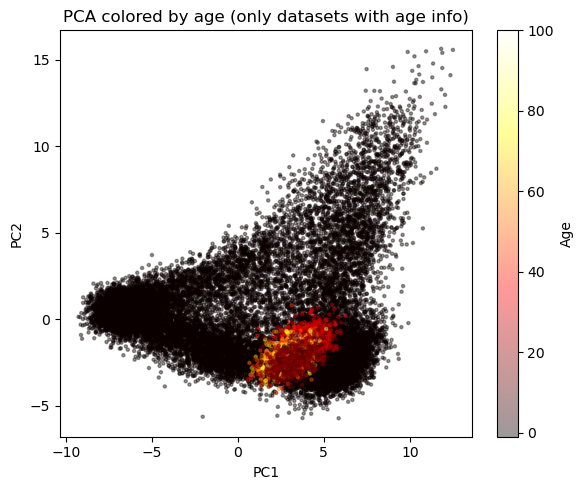

In [ ]:
# Look at huge_df where age is defined. Then plot the pca space colored by age.
huge_df_age = huge_df[huge_df["age"].notna()]
plt.figure(figsize=(6,5))
plt.scatter(sel_pca_result[huge_df["age"].notna(), 0], sel_pca_result[huge_df["age"].notna(), 1],
            c=huge_df["age"], # [huge_df_age["age"].loc[i] for i in huge_df["age"].notna() if huge_df_age["age"].loc[i] != -1 else 0], 
            cmap="hot", # viridis", 
            s=5, 
            alpha=0.4) # s=20, edgecolors="none")
plt.colorbar(label="Age")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA colored by age (only datasets with age info)")
plt.tight_layout()


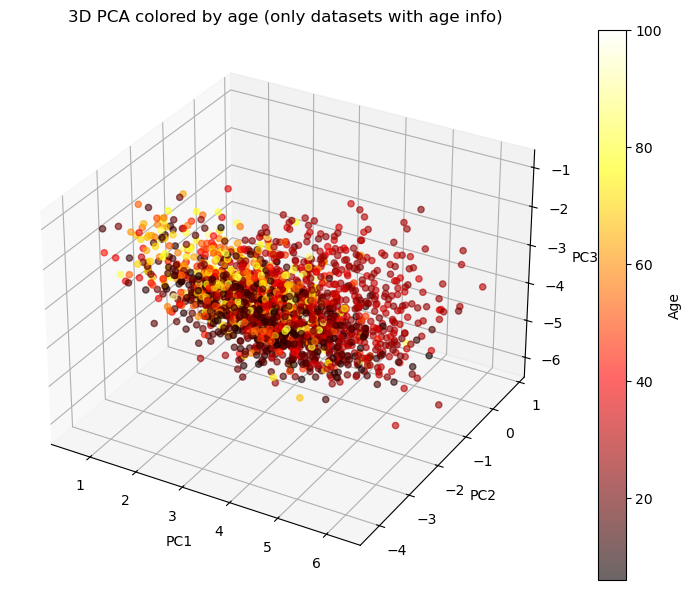

In [ ]:
# Now in 3D: Look at huge_df where age is defined. Then plot the pca space colored by age. Make it interactive. 
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(sel_pca_result[huge_df["age"].notna(), 0], 
                     sel_pca_result[huge_df["age"].notna(), 1], 
                     sel_pca_result[huge_df["age"].notna(), 2],
                     c=huge_df_age["age"], 
                     cmap="hot",
                     s=20,
                     alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA colored by age (only datasets with age info)")
plt.tight_layout()
plt.show()

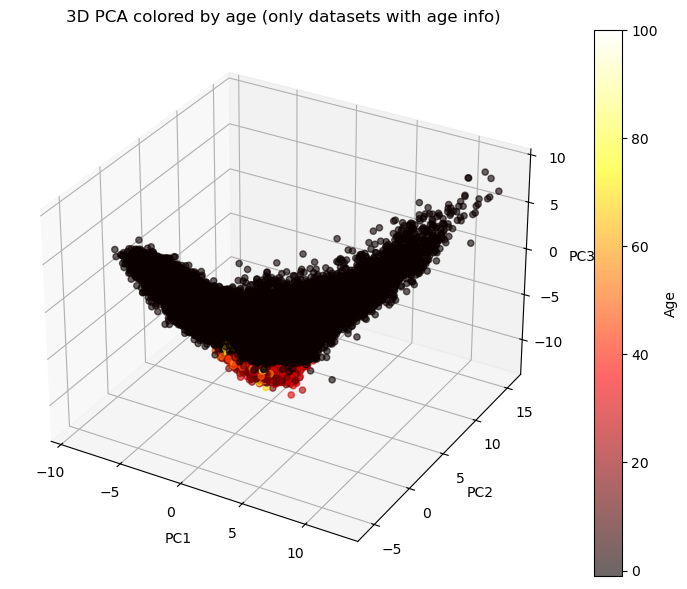

In [ ]:
# Now in 3D: Look at huge_df where age is defined. Then plot the pca space colored by age. Make it interactive. 
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(sel_pca_result[:, 0], 
                     sel_pca_result[:, 1], 
                     sel_pca_result[:, 2],
                     c=huge_df["age"], 
                     cmap="hot",
                     s=20,
                     alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA colored by age (only datasets with age info)")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({
    'PC1': sel_pca_result[:, 0],
    'PC2': sel_pca_result[:, 1],
    'PC3': sel_pca_result[:, 2],
    'age': huge_df["age"].values
})

fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3',
    color='age',
    color_continuous_scale='hot',
    opacity=0.6,
    size_max=10,
    title='3D PCA colored by age (only datasets with age info)'
)
fig.update_traces(marker=dict(size=3))
fig.show()

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


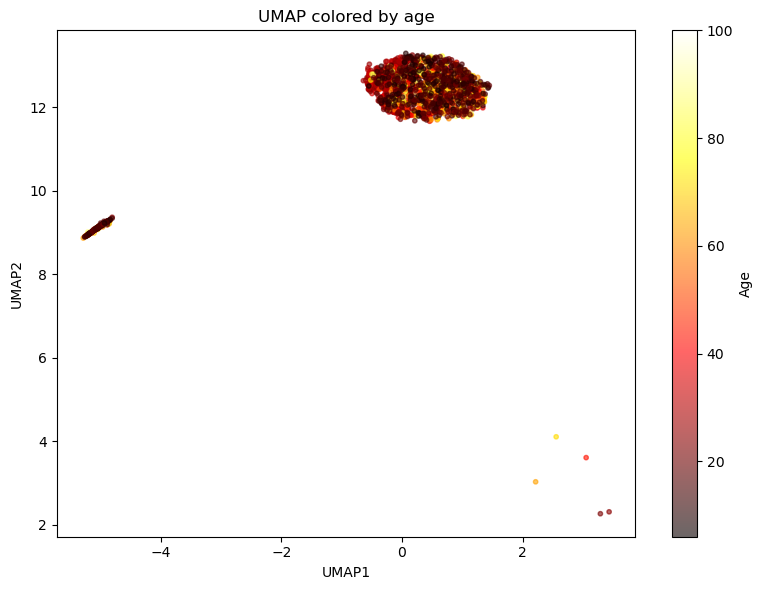

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Fit UMAP on all data, then visualize age-labeled subset
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Fit on the full dataset (or just age subset — your choice, see note below)
age_mask = huge_df["age"].notna()
embedding = reducer.fit_transform(sel_pca_result)  # use PCA result as input

# Plot only age-labeled points
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    # embedding[:, 0],
    # embedding[:, 1],
    embedding[age_mask, 0],
    embedding[age_mask, 1],
    c=huge_df_age["age"],
    cmap="hot",
    s=10,
    alpha=0.6
)
plt.colorbar(sc, label="Age")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP colored by age")
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



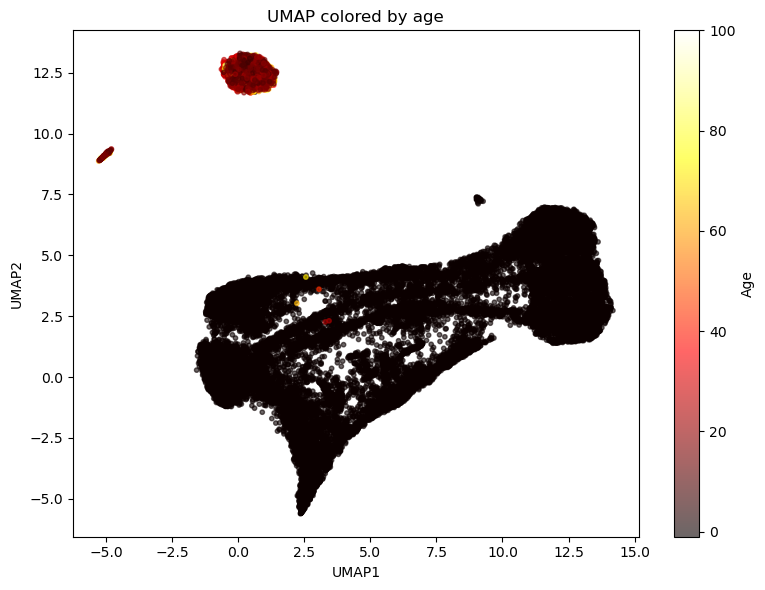

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Fit UMAP on all data, then visualize age-labeled subset
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Fit on the full dataset (or just age subset — your choice, see note below)
embedding = reducer.fit_transform(sel_pca_result)  # use PCA result as input

# Plot only age-labeled points
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=huge_df_age["age"],
    cmap="hot",
    s=10,
    alpha=0.6
)
plt.colorbar(sc, label="Age")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP colored by age")
plt.tight_layout()
plt.show()

In [ ]:
# PHATE is actually purpose-built for continuous gradients
import phate
phate_op = phate.PHATE(n_components=2, random_state=42)
embedding_phate = phate_op.fit_transform(sel_pca_result[age_mask])

Calculating PHATE...
  Running PHATE on 2019 observations and 10 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.03 seconds.
    Calculating affinities...
    Calculated affinities in 0.36 seconds.
  Calculated graph and diffusion operator in 0.40 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.06 seconds.
    Calculating KMeans...
    Calculated KMeans in 0.77 seconds.
  Calculated landmark operator in 0.84 seconds.
  Calculating optimal t...
    Automatically selected t = 24
  Calculated optimal t in 0.27 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.08 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 0.97 seconds.
Calculated PHATE in 2.69 seconds.


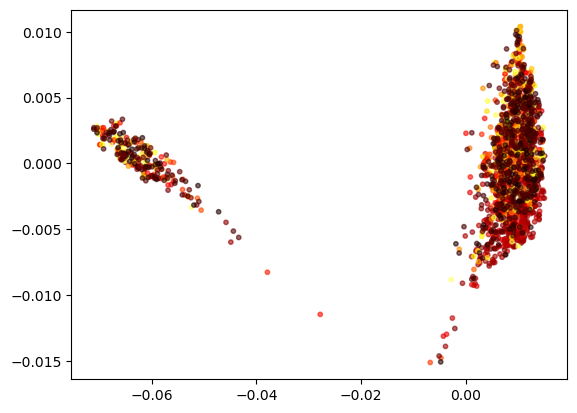

In [ ]:
plt.scatter(embedding_phate[:, 0], embedding_phate[:, 1], c=huge_df_age["age"], cmap="hot", s=10, alpha=0.6)

In [ ]:
age_mask

0        False
1        False
2        False
3        False
4        False
         ...  
27241     True
27242     True
27243    False
27244    False
27245    False
Name: age, Length: 27246, dtype: bool

In [ ]:
# Which datasets are in that isolated cluster?
from sklearn.cluster import DBSCAN

clusters = DBSCAN(eps=0.5, min_samples=5).fit_predict(embedding)
# print(huge_df_age[age_mask].groupby(clusters)["dataset"].value_counts())  # or species/source column

In [ ]:
clusters

array([0, 0, 0, ..., 0, 0, 0], shape=(27246,))

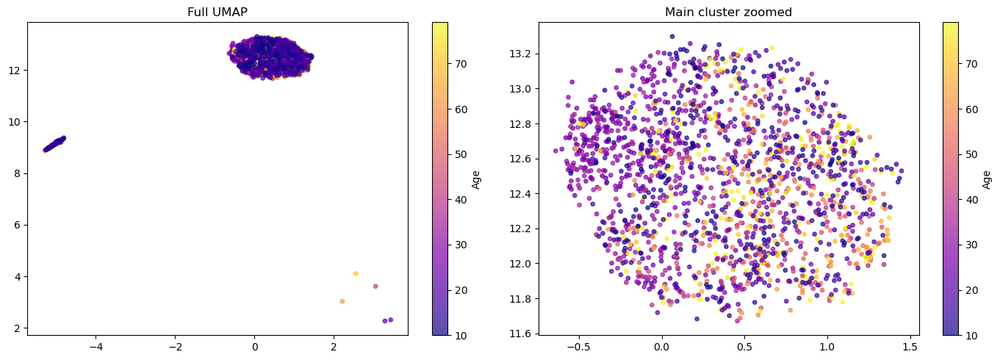

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full view
# Right: zoomed to main cluster
main = (embedding[:, 0] > -2) & (embedding[:, 1] > 10)  # adjust to your blob

for ax, mask in zip(axes, [age_mask, age_mask & main]):
    sc = ax.scatter(embedding[mask, 0], embedding[mask, 1],
                    c=huge_df_age["age"][mask],  # adjust indexing
                    cmap="plasma",   # better perceptual uniformity than "hot"
                    s=15, alpha=0.7,
                    vmin=np.percentile(huge_df_age["age"], 5),   # clip outliers
                    vmax=np.percentile(huge_df_age["age"], 95))
    plt.colorbar(sc, ax=ax, label="Age")

axes[0].set_title("Full UMAP")
axes[1].set_title("Main cluster zoomed")
plt.tight_layout()
plt.show()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/808219703.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (label, grp) in zip(axes, huge_df_age.assign(bin=age_bins).groupby("bin")):


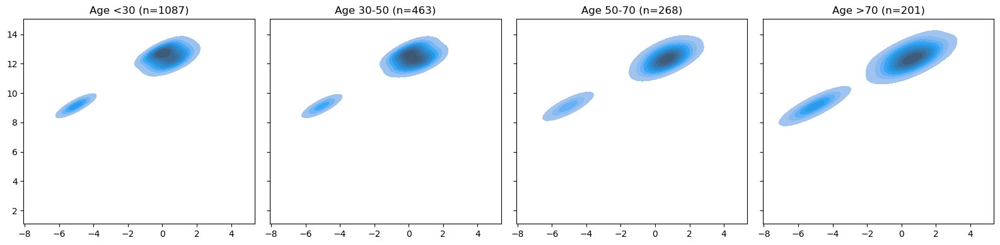

In [ ]:
import seaborn as sns

age_bins = pd.cut(huge_df_age["age"], bins=[0, 30, 50, 70, 100], 
                  labels=["<30", "30-50", "50-70", ">70"])

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
for ax, (label, grp) in zip(axes, huge_df_age.assign(bin=age_bins).groupby("bin")):
    idx = grp.index  # make sure this aligns with embedding rows
    sns.kdeplot(x=embedding[idx, 0], y=embedding[idx, 1], ax=ax, fill=True)
    ax.set_title(f"Age {label} (n={len(grp)})")
plt.tight_layout()

In [ ]:
from sklearn.metrics import pairwise_distances
from scipy.stats import f_oneway
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.utils import shuffle


X = pca_result[huge_df["age"].notna()][:, :2]  # PC1 + PC2 only
labels = sel_df_label[huge_df["age"].notna()]["dataset"].values

# # ── Extract the relevant PCA coordinates + labels ─────────────────────────────

# mami_mask  = (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
# tax_mask   = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE).values
# combined   = mami_mask.copy()
# combined[mami_mask] = tax_mask          # both conditions

# X      = sel_pca_result[combined, :2]   # PC1 + PC2 only
# labels = df_mami[tax_mask][taxonomy].values

# # ── Test 1: PERMANOVA (permutation-based MANOVA on distances) ─────────────────
# # "Are the groups more separated than random chance?"

# from sklearn.utils import shuffle

def permanova(X, labels, n_permutations=999):
    def f_stat(X, labels):
        groups  = [X[labels == g] for g in np.unique(labels)]
        grand_m = X.mean(axis=0)
        ss_between = sum(len(g) * ((g.mean(0) - grand_m)**2).sum() for g in groups)
        ss_within  = sum(((g - g.mean(0))**2).sum() for g in groups)
        k, n = len(groups), len(X)
        return (ss_between / (k-1)) / (ss_within / (n-k))

    observed = f_stat(X, labels)
    null_dist = [f_stat(X, shuffle(labels)) for _ in range(n_permutations)]
    p = (np.sum(np.array(null_dist) >= observed) + 1) / (n_permutations + 1)
    return observed, p

f_obs, p_perm = permanova(X, labels)
print(f"PERMANOVA  →  F = {f_obs:.3f},  p = {p_perm:.4f}")

# ── Test 2: Per-axis ANOVA ─────────────────────────────────────────────────────
# "Does any single PC axis separate the groups?"

groups_pc1 = [X[labels == g, 0] for g in np.unique(labels)]
groups_pc2 = [X[labels == g, 1] for g in np.unique(labels)]
f1, p1 = f_oneway(*groups_pc1)
f2, p2 = f_oneway(*groups_pc2)
print(f"ANOVA PC1  →  F = {f1:.3f},  p = {p1:.4f}")
print(f"ANOVA PC2  →  F = {f2:.3f},  p = {p2:.4f}")

# ── Test 3: LDA cross-validated accuracy ──────────────────────────────────────
# "Can we predict group membership better than chance?"

from sklearn.model_selection import cross_val_score
lda      = LinearDiscriminantAnalysis()
cv_score = cross_val_score(lda, X, labels, cv=5, scoring="accuracy").mean()
chance   = 1 / len(np.unique(labels))
print(f"LDA 5-fold CV accuracy = {cv_score:.3f}  (chance = {chance:.3f})")

PERMANOVA  →  F = 293.763,  p = 0.0010
ANOVA PC1  →  F = 267.967,  p = 0.0000
ANOVA PC2  →  F = 333.227,  p = 0.0000
LDA 5-fold CV accuracy = 0.553  (chance = 0.333)


ValueError: 'c' argument has 2019 elements, which is inconsistent with 'x' and 'y' with size 27246.

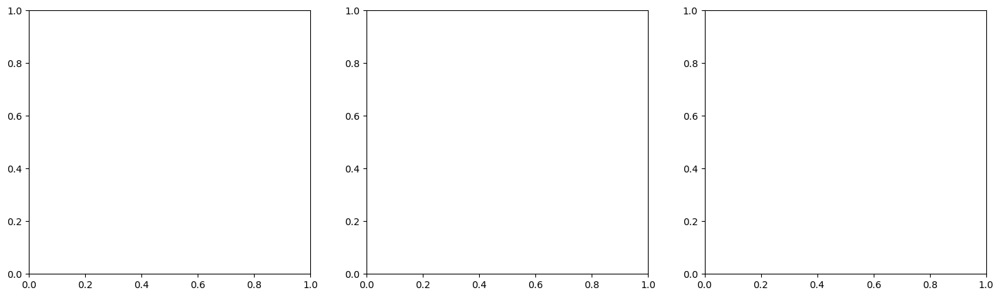

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

age_mask = huge_df["age"].notna()
X = huge_df[age_mask].drop(columns=["dataset", "age"]) #  sel_pca_result[age_mask]  # using PCA result as input (50 components recommended)
ages = huge_df_age["age"].values

# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, # ages,
                    cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

In [ ]:
age_mask = huge_df["age"] != -1
age_mask

0        False
1        False
2        False
3        False
4        False
         ...  
27241     True
27242     True
27243    False
27244    False
27245    False
Name: age, Length: 27246, dtype: bool

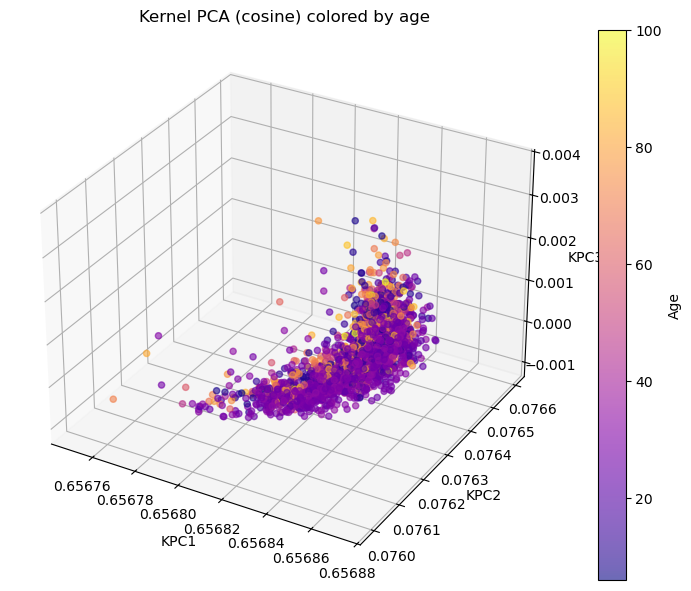

In [ ]:
# 3D plot of KPCA (cosine) colored by age
from mpl_toolkits.mplot3d import Axes3D
kpca = KernelPCA(n_components=3, kernel="cosine", random_state=42)
X_kpca = kpca.fit_transform(X)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

age_mask = huge_df["age"] != -1

scatter = ax.scatter(X_kpca[age_mask][:, 0], 
                     X_kpca[age_mask][:, 1], 
                     X_kpca[age_mask][:, 2],
                     c=ages, 
                     cmap="plasma",
                     s=20, alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("KPC1")
ax.set_ylabel("KPC2")
ax.set_zlabel("KPC3")
ax.set_title("Kernel PCA (cosine) colored by age")
plt.tight_layout()
plt.show()

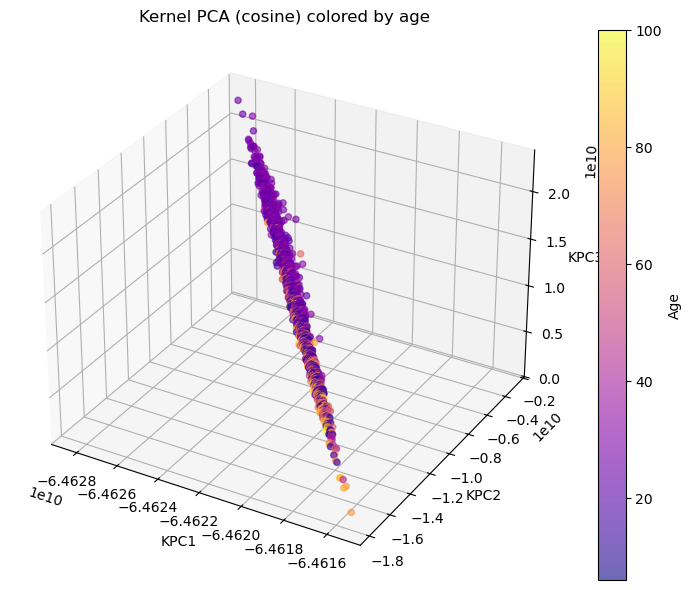

In [ ]:
# 3D plot of KPCA (poly) colored by age
from mpl_toolkits.mplot3d import Axes3D
kpca = KernelPCA(n_components=3, kernel="poly", random_state=42)
X_kpca = kpca.fit_transform(X)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

age_mask = huge_df["age"] != -1

scatter = ax.scatter(X_kpca[age_mask][:, 0], 
                     X_kpca[age_mask][:, 1], 
                     X_kpca[age_mask][:, 2],
                     c=ages, 
                     cmap="plasma",
                     s=20, alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("KPC1")
ax.set_ylabel("KPC2")
ax.set_zlabel("KPC3")
ax.set_title("Kernel PCA (cosine) colored by age")
plt.tight_layout()
plt.show()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/1339536815.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c=pd.factorize(huge_df_age[age_mask]["dataset"])[0],


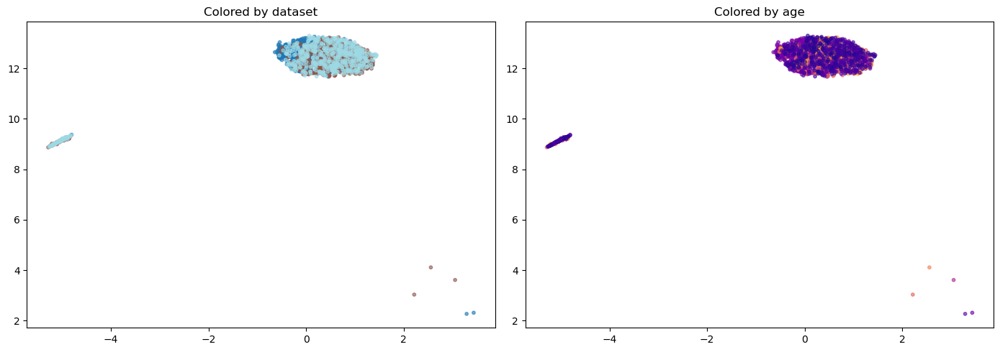

In [ ]:
# Color your existing UMAP/t-SNE by dataset instead of age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by dataset
sc1 = axes[0].scatter(embedding[age_mask, 0], embedding[age_mask, 1],
                       c=pd.factorize(huge_df_age[age_mask]["dataset"])[0],
                       cmap="tab20", s=10, alpha=0.6)
axes[0].set_title("Colored by dataset")

# Right: colored by age
sc2 = axes[1].scatter(embedding[age_mask, 0], 
                      embedding[age_mask, 1],
                       c=ages, # [age_mask], 
                       cmap="plasma", s=10, alpha=0.6)
axes[1].set_title("Colored by age")

plt.tight_layout()
plt.show()

In [ ]:
huge_df.keys()

Index(['transitivity', 'avg_clustering', 'modularity', 'degree_gini',
       'degree_assortativity', 'omega', 'structural_complexity',
       'directed_simplices_count', 'directed_simplices_max_size',
       'char_path_length', 'global_efficiency', 'diffusion_efficiency',
       'propagation_efficiency', 'avg_communicability',
       'topological_distance_mean', 'topological_distance_std',
       'avg_edge_distance', 'wiring_cost',
       'proportion_long_range_connections_0.1',
       'proportion_long_range_connections_0.3',
       'proportion_long_range_connections_0.3956',
       'proportion_long_range_connections_0.5', 'richclub_n_edges',
       'richclub_avg_length', 'rich_club_coefficient_rc_max_norm',
       'rich_club_coefficient_rc_mean_norm',
       'rich_club_coefficient_rc_k_at_max',
       'rich_club_coefficient_rc_regime_frac',
       'rich_club_coefficient_rc_weighted_auc', 'spectral_radius',
       'spectral_gap', 'synchronizability_eigenratio_eigenratio',
       'kerne

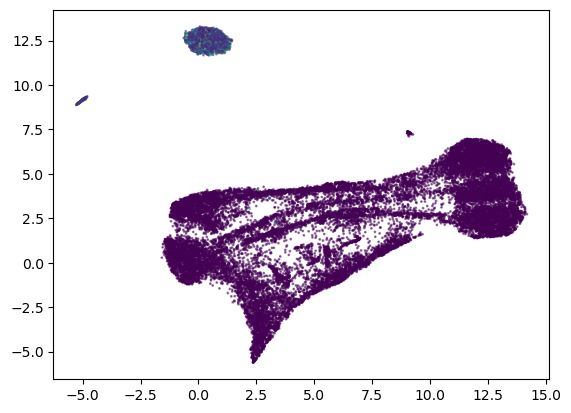

In [ ]:
plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=huge_df["age"].values,
            s=1, 
            alpha=0.5,
            )

(11.0, 14.0)

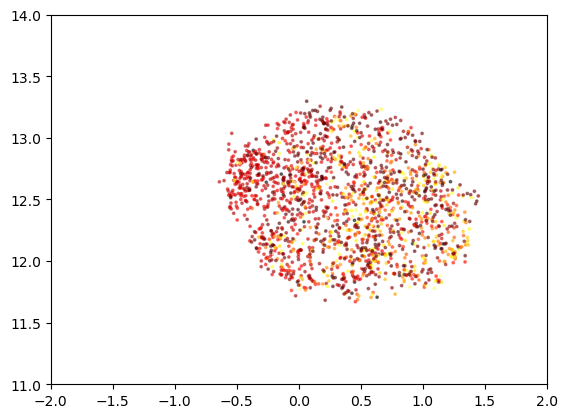

In [ ]:
plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=huge_df["age"].values,
            s=3, 
            alpha=0.5,
            cmap="hot",
            )

plt.xlim(-2, 2)
plt.ylim(11, 14)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/3966855115.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab20", len(unique_datasets))


Text(0.5, 1.0, 'UMAP colored by age and dataset')

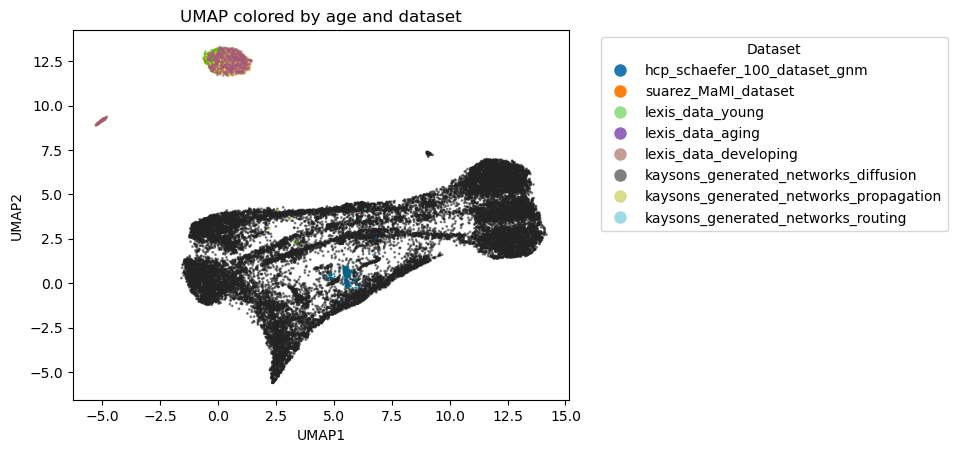

In [ ]:
colors_dataset = [COLOR_SCHEME[d] for d in huge_df["dataset"]]

plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=colors_dataset,
            s=1, 
            alpha=0.5,
            )

# Add legend for datasets
unique_datasets = huge_df["dataset"].unique()
color_map = plt.cm.get_cmap("tab20", len(unique_datasets))
dataset_colors = {ds: color_map(i) for i, ds in enumerate(unique_datasets)}
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=ds,
                              markerfacecolor=dataset_colors[ds], markersize=10)
                    for ds in unique_datasets],
           title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP colored by age and dataset")

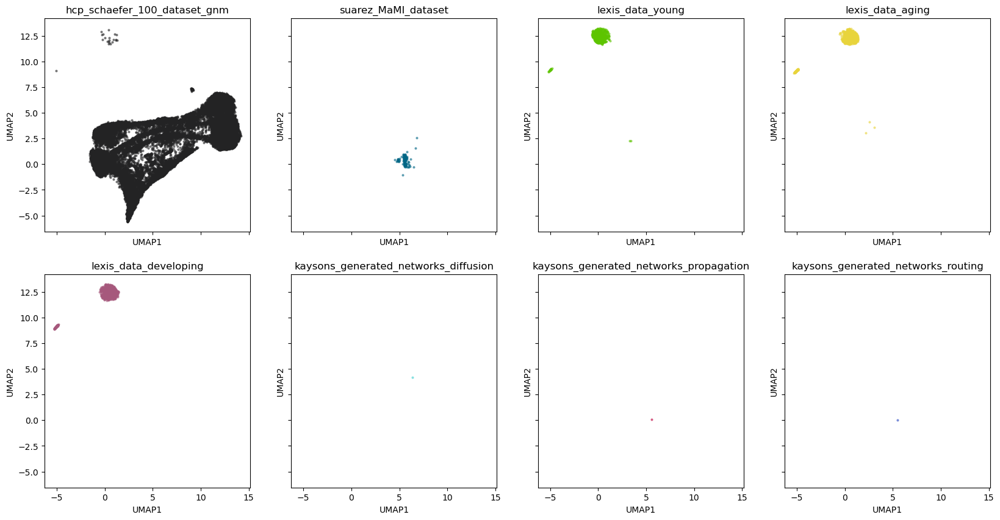

In [ ]:
# plot each dataset separately in a grid of subplots
unique_datasets = huge_df["dataset"].unique()
n = len(unique_datasets)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows), sharex=True, sharey=True)

for ax, dataset in zip(axes.flatten(), unique_datasets):
    mask = huge_df["dataset"] == dataset
    # convert to boolean array
    mask = mask.values.astype(bool)

    ax.scatter(embedding[mask, 0], 
               embedding[mask, 1], 
               c=COLOR_SCHEME[dataset], 
               s=4, #1
               alpha=0.5)
    
    ax.set_title(dataset)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/2596203960.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for i, dataset in enumerate(huge_df_age[age_mask]["dataset"].unique()): # Left: colored by dataset
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/2596203960.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  that_dataset_mask = (huge_df_age[age_mask]["dataset"] == dataset)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 27246 but size of corresponding boolean axis is 2019

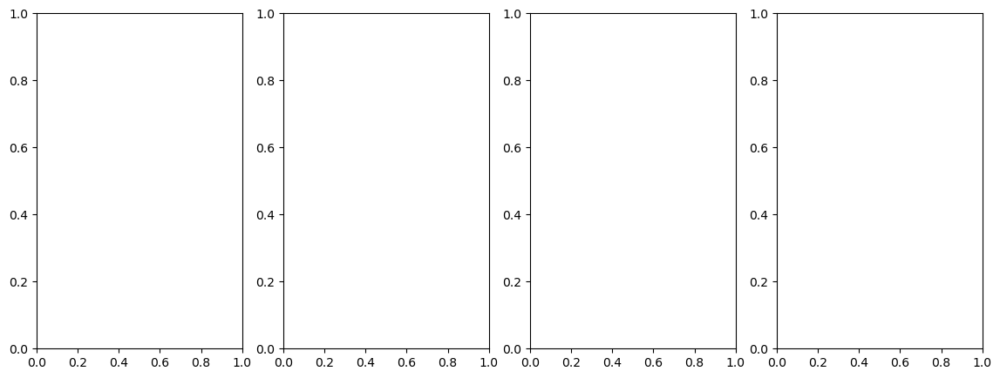

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(14, 5))

for i, dataset in enumerate(huge_df_age[age_mask]["dataset"].unique()): # Left: colored by dataset
    that_dataset_mask = (huge_df_age[age_mask]["dataset"] == dataset)
    sc1 = axs[i].scatter(embedding[that_dataset_mask, 0], 
                         embedding[that_dataset_mask, 1],
                        c=i, # pd.factorize(huge_df_age[that_dataset_mask][age_mask]["dataset"])[0],
                        cmap="tab20", s=10, alpha=0.6)
    axs[i].set_title("Colored by dataset")

In [ ]:
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(huge_df.drop("dataset", "age")) # _properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=2, 
            alpha=0.4, 
            c=huge_df['color_dataset'], 
            # label=huge_df['dataset']
        )
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

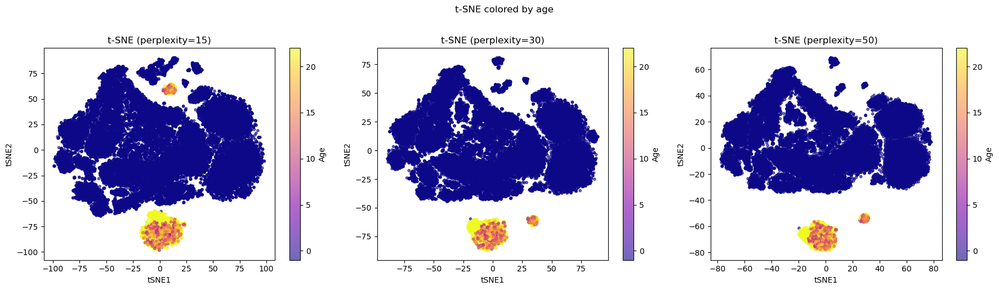

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

# age_mask = huge_df["age"].notna()
X = huge_df.drop(columns=["dataset", "age"]) #  sel_pca_result[age_mask]  # using PCA result as input (50 components recommended)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ages = huge_df_age["age"].values
ages_or_gray = huge_df["age"].values  # use age where available, else gray
ages_or_gray[huge_df["age"].isna()] = -1  # set missing ages to -1 for gray color
# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages_or_gray, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages_or_gray, 5),
                    vmax=np.percentile(ages_or_gray, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

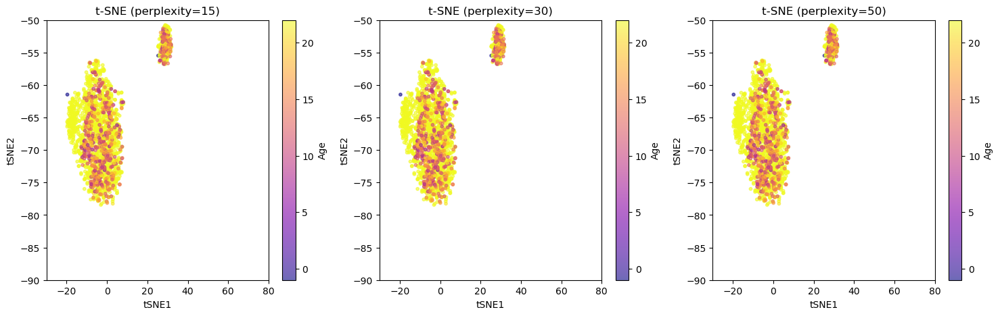

In [ ]:
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    # tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    # emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages_or_gray, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages_or_gray, 5),
                    vmax=np.percentile(ages_or_gray, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_xlim(-30, 80)
    ax.set_ylim(-90, -50)
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

ValueError: 'c' argument has 2019 elements, which is inconsistent with 'x' and 'y' with size 27246.

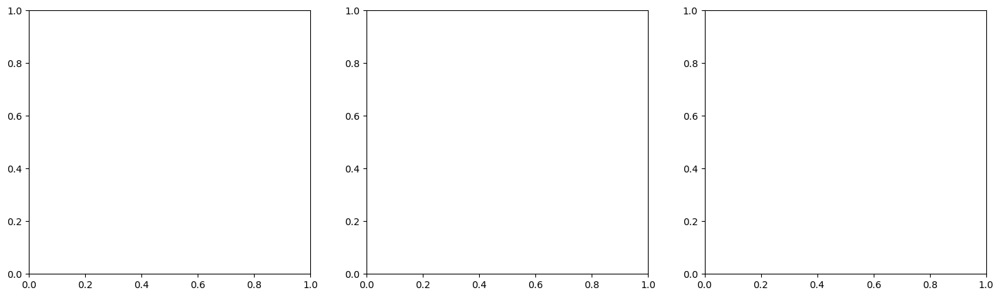

In [ ]:


# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

# age_mask = huge_df["age"].notna()
X = sel_pca_result # [age_mask]  # using PCA result as input (50 components recommended)
ages = huge_df_age["age"].values

# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/392888112.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ages = huge_df_age[age_mask]["age"].values.astype(np.float32)    # continuous label
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_91278/392888112.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  groups = huge_df_age[age_mask]["dataset"].values              # for dataset-aware CV
pos: -0.7157 neg:  6.4783 total:  5.7626 temperature:  1.0000: 100%|██████████| 5000/5000 [28:25<00:00,  2.93it/s]
pos: -0.9854 neg:  6.4002 total:  5.4147 temperature:  1.0000: 100%|██████████| 5000/5000 [27:42<00:00,  3.01it/s]


<function matplotlib.pyplot.show(close=None, block=None)>

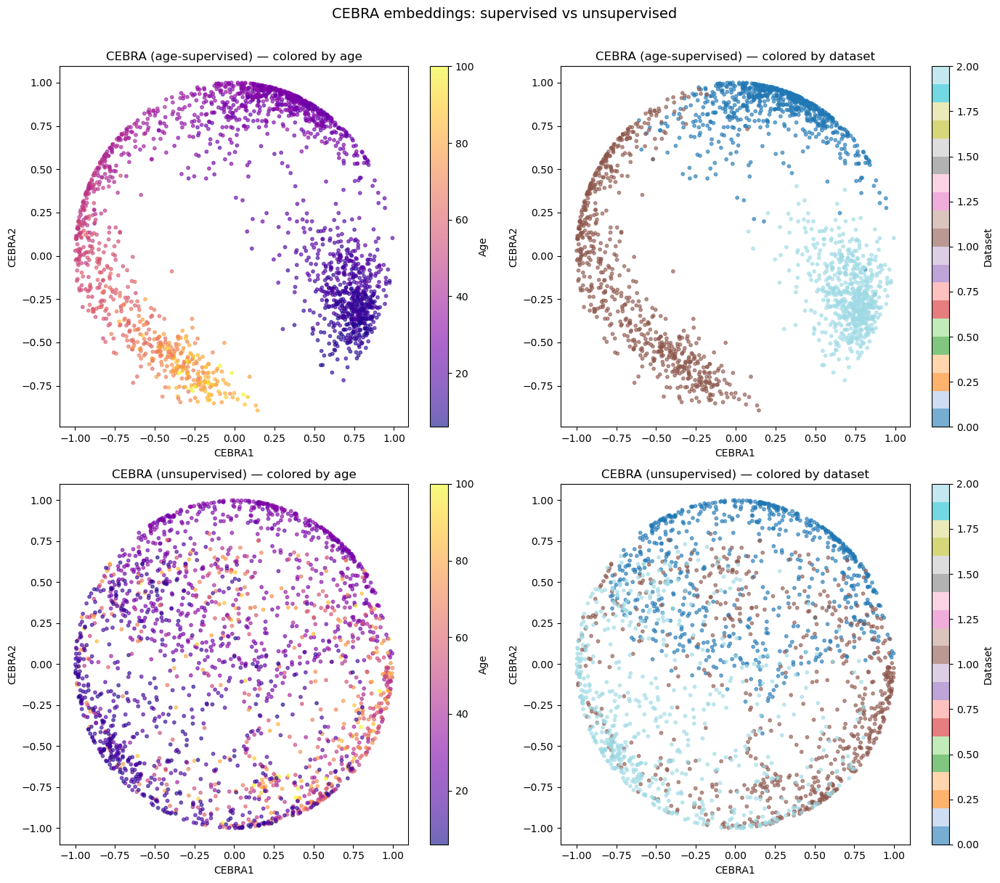

In [ ]:
import cebra
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
import pandas as pd

# ── Setup ──────────────────────────────────────────────────────────────────────
age_mask = huge_df["age"] != -1  #  huge_df["age"].notna() &only rows with age and dataset info
X = sel_pca_result[age_mask].astype(np.float32)        # input: PCA features
ages = huge_df_age[age_mask]["age"].values.astype(np.float32)    # continuous label
groups = huge_df_age[age_mask]["dataset"].values              # for dataset-aware CV

# ── 1. CEBRA with age as the conditioning variable (supervised) ────────────────
cebra_model = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    temperature=1.0,
    output_dimension=3,          # 3D embedding
    max_iterations=5000,
    verbose=True,
    device="cpu"                 # change to "cuda" if available
)

# Fit conditioned on age — this is the key difference from PCA/UMAP/t-SNE
cebra_model.fit(X, ages)
embedding_age = cebra_model.transform(X)

# ── 2. CEBRA without label (unsupervised) for comparison ──────────────────────
cebra_model_unsup = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    output_dimension=3,
    max_iterations=5000,
    verbose=True,
    device="cpu"
)
cebra_model_unsup.fit(X)
embedding_unsup = cebra_model_unsup.transform(X)

# ── 3. Visualize: supervised vs unsupervised, colored by age AND dataset ───────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

dataset_ids = pd.factorize(groups)[0]

plots = [
    (embedding_age,  ages,        "plasma", "CEBRA (age-supervised) — colored by age"),
    (embedding_age,  dataset_ids, "tab20",  "CEBRA (age-supervised) — colored by dataset"),
    (embedding_unsup, ages,       "plasma", "CEBRA (unsupervised) — colored by age"),
    (embedding_unsup, dataset_ids,"tab20",  "CEBRA (unsupervised) — colored by dataset"),
]

for ax, (emb, color, cmap, title) in zip(axes.flat, plots):
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=color, cmap=cmap, s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="Age" if cmap == "plasma" else "Dataset")
    ax.set_title(title)
    ax.set_xlabel("CEBRA1")
    ax.set_ylabel("CEBRA2")

plt.suptitle("CEBRA embeddings: supervised vs unsupervised", y=1.01, fontsize=14)
plt.tight_layout()
plt.show